# Week 6 — Trading Costs, Execution, and Common Benchmarks

[Open this notebook in Google Colab](https://colab.research.google.com/github/KennethWYLee/FinTech/blob/main/course/week6_main.ipynb)

The course repository is public. If the direct Colab link is temporarily unavailable, download `week6_main.ipynb` from GitHub and upload it to Colab.

Start with fixed positions, express each cost in consistent units, and examine how execution delay and turnover change net wealth. Compare cash, buy-and-hold and simple rules without claiming risk-adjusted superiority.

Every source-grounded example uses fixed AAPL or AAPL/MSFT daily observations accessed through yfinance. The prices, dates, and derived returns come from that recorded request. Commission, bid–ask spread, slippage, execution delay, portfolio value, and supplied weights are instructor-created assumptions unless a cell explicitly states otherwise. Daily yfinance data do not contain the order, quote, fill, or broker records needed to measure an investor's realized trading cost.

## Core financial question

How do stated execution and transaction-cost assumptions convert a gross historical trading result into a reproducible net result, and what does each common benchmark add to the comparison?

Run from top to bottom. Predict each named result, then use the output to check your reasoning.

## Observable outcome

After completing Week 6, you will produce a dated cost-and-execution ledger in which every net return can be reconstructed from gross return, one-way turnover, and stated cost components. You will also show how an additional execution delay changes positions and turnover, identify whether a conclusion changes within a prespecified cost range, and compare common benchmarks under compatible dates and cost conventions.

## Learning objectives

After completing Week 6, you should be able to:

- distinguish source-grounded prices and returns from quoted, measured, or assumed transaction-cost inputs;
- convert basis points, percentage rates, fixed US-dollar commissions, quoted spreads, and slippage into compatible deductions;
- calculate one-way turnover, entry and exit charges, period net return, and compounded net wealth;
- realign positions for an additional execution delay and recalculate the delayed path's own turnover;
- hold positions and dates fixed while conducting cost-sensitivity and break-even calculations; and
- explain the separate questions answered by cash, buy-and-hold, rule-based, and equal-weighted benchmarks.

## Before you begin

Complete Week 5 or bring a dated position series whose positions apply to later return intervals. Use Google Colab or a local Jupyter environment with Python, `numpy`, `pandas`, `matplotlib`, and `yfinance`. Source-grounded cells require internet access when the notebook is executed from a fresh environment.

The fixed cost values in this notebook are teaching assumptions. They are not the approved Report 1 settings and must not replace a broker schedule, quote record, execution record, or market-impact analysis required by a different financial question.

# Navigation through the twenty issues

| Section | Issues | Main decision | Evidence carried forward |
|---|---:|---|---|
| Cost inputs and units | 1–7 | Which inputs are observed or assumed, and how are they converted without double counting? | Cost convention with units and evidence status |
| Turnover and net-return accounting | 8–11 | Which position changes are charged, and how do costs enter period returns and wealth? | Dated gross, turnover, cost, net-return, and wealth ledger |
| Execution delay | 12–13 | Which later return interval is held, and why must the delayed path recalculate turnover? | Original and delayed positions with separate cost ledgers |
| Sensitivity and break-even | 14–15 | Which cost value changes a stated comparison while all other inputs remain fixed? | Prespecified cost grid and bounded break-even conclusion |
| Common benchmarks and claim boundary | 16–20 | What does cash, buy-and-hold, a rule-based benchmark, or equal weighting answer? | Comparison under common conditions and limits before Week 7 |

```text
position selected before a return interval
        ↓ compare with the preceding held position
one-way turnover
        ↓ apply stated commission, spread, and slippage assumptions
period transaction cost
        ↓ subtract from gross return on the stated accounting date
net return and net wealth
```

Week 6 stops at net return, wealth, turnover, and common-condition comparison. Week 7 adds annualized return, volatility, Sharpe and Sortino ratios, drawdown, statistical uncertainty, repeated selection, and the full backtest audit.

# Fixed data and accounting assumptions

AAPL and MSFT daily observations are requested from 2024-01-02 inclusive to 2025-01-03 exclusive. Yahoo Close is split-adjusted; these calculations do not add dividends. Stored dates are not independent evidence of a complete exchange calendar.

Signals are calculated after Close $d$. The base rule assumes execution at Close $d+1$ and earns the return ending at Close $d+2$. Thus the position on a return-ending row $t$ uses signal $t-2$. Initial exposure is cash; no extra liquidation is appended after the final evaluated interval. Buy-and-hold is specified in advance and enters at the initial price boundary.

All strategies use an additive cost deduction: gross return minus turnover times the assumed one-way rate. Cost is expressed in units of the interval's opening wealth and booked on its return-ending row. This is a linear teaching approximation, not an exact share-and-cash settlement account. Paying a cost before investing would also change investable capital; that alternative needs explicit cash accounting.

The default assumed one-way cost is 4 basis points: commission 1, half-spread 2, and **additional** adverse execution shortfall 1 beyond that half-spread. A measured midpoint-to-fill shortfall already contains spread and must not be added again. Daily prices provide neither these costs nor actual fills.

In [1]:
# Purpose: Load dependencies and validate the source response — calculate the controlled inputs and result.
from importlib.metadata import PackageNotFoundError, version
import platform

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

try:
    import yfinance as yf
    YFINANCE_VERSION = version("yfinance")
except (ImportError, PackageNotFoundError):
    yf = None
    YFINANCE_VERSION = "not installed"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 170)
plt.rcParams.update(
    {
        "figure.figsize": (7.6, 3.8),
        "figure.dpi": 110,
        "axes.grid": True,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

SOURCE_REQUEST = {
    "start": "2024-01-02",
    "end": "2025-01-03",
    "interval": "1d",
    "auto_adjust": False,
    "actions": False,
    "progress": False,
    "threads": False,
    "multi_level_index": False,
}
TEACHING_COMMISSION_BP = 1.0
TEACHING_FULL_SPREAD_BP = 4.0
TEACHING_HALF_SPREAD_BP = TEACHING_FULL_SPREAD_BP / 2
TEACHING_SLIPPAGE_BP = 1.0
TEACHING_TOTAL_ONE_WAY_BP = (
    TEACHING_COMMISSION_BP
    + TEACHING_HALF_SPREAD_BP
    + TEACHING_SLIPPAGE_BP
)


def load_us_daily(symbol):
    if yf is None:
        raise ModuleNotFoundError(
            "Install yfinance before running the source-grounded Week 6 examples."
        )
    rows = yf.download(tickers=symbol, **SOURCE_REQUEST)
    if isinstance(rows.columns, pd.MultiIndex):
        rows.columns = rows.columns.get_level_values(0)
    rows.index = pd.DatetimeIndex(rows.index).tz_localize(None)
    required = {"Open", "High", "Low", "Close", "Volume"}
    if rows.empty or not required.issubset(rows.columns):
        raise ValueError(f"The fixed {symbol} request returned no usable OHLCV response.")
    if not rows.index.is_monotonic_increasing:
        raise ValueError("Source dates must already be increasing.")
    if not np.isfinite(rows[['Open','Close']].to_numpy()).all() or not rows[['Open','Close']].gt(0).all().all():
        raise ValueError("Price endpoints must be finite and positive.")
    if rows.index.min() < pd.Timestamp(SOURCE_REQUEST['start']) or rows.index.max() >= pd.Timestamp(SOURCE_REQUEST['end']):
        raise ValueError("Source dates are outside request boundaries.")
    if not rows.index.is_unique:
        raise ValueError(f"The fixed {symbol} response contains duplicate dates.")
    return rows


def one_way_turnover(position, initial_position=0.0):
    position = pd.Series(position, dtype=float)
    if position.empty or not np.isfinite(position).all():
        raise ValueError("Positions must be a nonempty finite series.")
    if not position.between(0,1).all() or not np.isfinite(initial_position) or not 0 <= initial_position <= 1:
        raise ValueError("This example allows only long-or-cash exposure from 0 to 1.")
    previous = position.shift(1)
    previous.iloc[0] = initial_position
    return (position - previous).abs()


def cost_ledger(position, asset_return, total_cost_bp, initial_position=0.0):
    position = pd.Series(position, dtype=float)
    asset_return = pd.Series(asset_return, dtype=float)
    if not asset_return.index.equals(position.index):
        raise ValueError("Positions and returns must have identical ordered dates.")
    if asset_return.isna().any() or not np.isfinite(asset_return).all():
        raise ValueError("Every held interval must have one finite asset return.")
    if not np.isfinite(total_cost_bp) or total_cost_bp < 0:
        raise ValueError("The one-way cost in basis points must be finite and nonnegative.")
    turnover = one_way_turnover(position, initial_position)
    gross_return = position * asset_return
    cost = turnover * total_cost_bp / 10_000
    net_return = gross_return - cost
    if (1 + gross_return).le(0).any() or (1 + net_return).le(0).any():
        raise ValueError("The positive-wealth example excludes nonpositive wealth factors.")
    return pd.DataFrame(
        {
            "asset_return": asset_return,
            "position": position,
            "one_way_turnover": turnover,
            "gross_return": gross_return,
            "cost_return_units": cost,
            "net_return": net_return,
            "gross_wealth": (1 + gross_return).cumprod(),
            "net_wealth": (1 + net_return).cumprod(),
        }
    )


def show_figure_with_alt_text(figure, alt_text):
    if not isinstance(alt_text, str) or not alt_text.strip():
        raise ValueError("Figure alternative text must be a nonempty string.")
    display(figure, metadata={"image/png": {"alt": alt_text.strip()}})
    display(Markdown("**Figure.** " + alt_text.strip()))
    plt.close(figure)


environment = pd.Series(
    {
        "Python interface": "Jupyter kernel",
        "Python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": mpl.__version__,
        "yfinance": YFINANCE_VERSION,
        "Cost values": "Instructor-created teaching assumptions",
    },
    name="Value",
)
display(environment.rename_axis("Environment item").to_frame())

,Value
Environment item,
Python interface,Jupyter kernel
Python,3.12.9
numpy,2.2.6
pandas,2.2.3
matplotlib,3.10.8
yfinance,1.2.0
Cost values,Instructor-created teaching assumptions


In [2]:
# Purpose: Align AAPL/MSFT dates and construct signals with next-Close execution.
aapl = load_us_daily("AAPL")
msft = load_us_daily("MSFT")

if not aapl.index.equals(msft.index):
    raise ValueError("AAPL and MSFT dates differ; resolve coverage before comparing.")
source_prices = pd.concat(
    {"AAPL": aapl["Close"], "MSFT": msft["Close"]}, axis=1, join="inner"
)
source_returns = source_prices.pct_change(fill_method=None).iloc[1:]

aapl_frame = aapl[["Open", "Close"]].copy()
aapl_frame["asset_return"] = aapl_frame["Close"].pct_change(fill_method=None)
aapl_frame["momentum_5"] = aapl_frame["Close"] / aapl_frame["Close"].shift(5) - 1
aapl_frame["momentum_20"] = aapl_frame["Close"] / aapl_frame["Close"].shift(20) - 1
aapl_frame["signal_5"] = np.where(
    aapl_frame["momentum_5"].isna(), np.nan, (aapl_frame["momentum_5"] > 0).astype(float)
)
aapl_frame["signal_20"] = np.where(
    aapl_frame["momentum_20"].isna(), np.nan, (aapl_frame["momentum_20"] > 0).astype(float)
)
aapl_frame["position_5"] = pd.Series(
    aapl_frame["signal_5"], index=aapl_frame.index
).shift(2).fillna(0.0)
aapl_frame["position_20"] = pd.Series(
    aapl_frame["signal_20"], index=aapl_frame.index
).shift(2).fillna(0.0)
source_eval = aapl_frame.iloc[1:].copy()
source_eval["execution_date"] = aapl_frame.index.to_series().shift(1).reindex(source_eval.index)
source_eval["signal_date"] = aapl_frame.index.to_series().shift(2).reindex(source_eval.index)

request_summary = pd.Series(
    {
        "Symbols": "AAPL and MSFT",
        "Start boundary": "2024-01-02 inclusive",
        "End boundary": "2025-01-03 exclusive",
        "Observation interval": "1 day",
        "Price field used for returns": "Close",
        "auto_adjust": False,
        "Return meaning": "Close-to-close price return; cash dividends not added",
        "Cost evidence": "Instructor-created assumptions shown separately",
    },
    name="Recorded setting",
)
display(request_summary.to_frame())
source_summary = pd.DataFrame(
    [
        ("AAPL", len(aapl), str(aapl.index.min().date()), str(aapl.index.max().date())),
        ("MSFT", len(msft), str(msft.index.min().date()), str(msft.index.max().date())),
        ("Common return intervals", len(source_returns), str(source_returns.index.min().date()), str(source_returns.index.max().date())),
    ],
    columns=["Item", "Rows", "First date", "Last date"],
)
display(source_summary.style.hide(axis="index").set_caption("Fixed US-stock requests used in Week 6"))
assert len(aapl) > 200 and len(msft) > 200 and len(source_returns) > 200
assert source_returns.index.is_monotonic_increasing
assert np.isfinite(source_returns.to_numpy()).all()

,Recorded setting
Symbols,AAPL and MSFT
Start boundary,2024-01-02 inclusive
End boundary,2025-01-03 exclusive
Observation interval,1 day
Price field used for returns,Close
auto_adjust,False
Return meaning,Close-to-close price return; cash dividends no...
Cost evidence,Instructor-created assumptions shown separately


Item,Rows,First date,Last date
AAPL,253,2024-01-02,2025-01-02
MSFT,253,2024-01-02,2025-01-02
Common return intervals,252,2024-01-03,2025-01-02


## Issue 1 — Which transaction-cost inputs are observed, quoted, assumed, or still unavailable?


A net backtest needs more than one unlabeled `cost` number. For each component, record the financial quantity, unit, reference price or transaction, source, retrieval date, and whether the value is observed from an execution, quoted before execution, assumed for sensitivity analysis, or still unavailable.

A broker commission schedule can document a quoted fee but not the price actually obtained. A bid and ask can document a quoted spread at a particular instant but not an investor's fill. Slippage requires a stated reference price and an execution price. Market impact requires evidence about how the order itself affected available prices. These inputs cannot be recovered from daily closing prices alone.


### Connection to documented sources

Investor.gov distinguishes fees charged by transaction from other fee structures and asks investors to identify total purchase and sale fees. The yfinance documentation describes a historical market-data interface; it does not document an investor's orders, quotes, executions, or brokerage fees.

Sources: [Investor.gov on understanding fees](https://www.investor.gov/introduction-investing/getting-started/understanding-fees) and the [yfinance download documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

Predict which two rows in the table cannot be classified as measured execution evidence and state the missing record for each.

In [3]:
# Purpose: Issue 1 — Which transaction-cost inputs are observed, quoted, assumed, or still unavailable? — calculate the controlled inputs and result.
controlled_cost_inputs = pd.DataFrame(
    [
        ("Commission", "USD per order", "Broker schedule", "Quoted"),
        ("Bid–ask spread", "Basis points of midpoint", "Quote snapshot", "Quoted"),
        ("Slippage", "Basis points from reference price", "Order and fill record", "Measured"),
        ("Market impact", "Price change attributable to the order", "No record supplied", "Pending"),
    ],
    columns=["Cost component", "Required unit", "Available record", "Evidence status"],
)
display(controlled_cost_inputs.style.hide(axis="index").set_caption("Artificial transaction-cost input inventory"))
status_count = controlled_cost_inputs["Evidence status"].value_counts().rename("Rows")
display(status_count.to_frame())
assert status_count.to_dict() == {"Quoted": 2, "Measured": 1, "Pending": 1}

Cost component,Required unit,Available record,Evidence status
Commission,USD per order,Broker schedule,Quoted
Bid–ask spread,Basis points of midpoint,Quote snapshot,Quoted
Slippage,Basis points from reference price,Order and fill record,Measured
Market impact,Price change attributable to the order,No record supplied,Pending


,Rows
Evidence status,
Quoted,2
Measured,1
Pending,1


### Interpret Code 1

The artificial inventory contains two quoted rows, one measured row, and one pending row. The commission and spread are not measured fills; the market-impact row lacks any order-book or execution evidence. Only the slippage row identifies both the reference and fill record required by its definition.

### Source-grounded example

Code 2 separates the source-grounded AAPL date and closing-price record from the instructor-created cost assumptions used later. It does not display the downloaded market row.

### Before Code 2

Predict the counts of source-grounded, assumed, and unavailable items in the displayed boundary table.

In [4]:
# Purpose: Issue 1 — Which transaction-cost inputs are observed, quoted, assumed, or still unavailable? — evaluate the stated source-derived data.
first_source_date = aapl.index[0]
source_boundary = pd.DataFrame(
    [
        ("AAPL Close and date", "yfinance/Yahoo Finance fixed request", "Source-grounded"),
        ("Commission: 1 basis point", "Instructor-created value", "Assumed"),
        ("Quoted full spread: 4 basis points", "Instructor-created value", "Assumed"),
        ("Slippage: 1 basis point", "Instructor-created value", "Assumed"),
        ("Investor order and execution record", "Not present in daily OHLCV", "Unavailable"),
    ],
    columns=["Item", "Origin", "Evidence status"],
)
source_boundary["Recorded market date"] = [str(first_source_date.date()), "Not applicable", "Not applicable", "Not applicable", "Not available"]
display(source_boundary.style.hide(axis="index").set_caption("AAPL source evidence and Week 6 teaching assumptions"))
source_status_count = source_boundary["Evidence status"].value_counts().rename("Rows")
display(source_status_count.to_frame())
assert source_status_count.to_dict() == {"Assumed": 3, "Source-grounded": 1, "Unavailable": 1}

Item,Origin,Evidence status,Recorded market date
AAPL Close and date,yfinance/Yahoo Finance fixed request,Source-grounded,2024-01-02
Commission: 1 basis point,Instructor-created value,Assumed,Not applicable
Quoted full spread: 4 basis points,Instructor-created value,Assumed,Not applicable
Slippage: 1 basis point,Instructor-created value,Assumed,Not applicable
Investor order and execution record,Not present in daily OHLCV,Unavailable,Not available


,Rows
Evidence status,
Assumed,3
Source-grounded,1
Unavailable,1


### Interpret Code 2

The table contains one source-grounded market item, three assumed cost inputs, and one unavailable execution record. The source-grounded row is dated 2024-01-02. These records allow a reproducible sensitivity calculation but do not establish the commission, spread, slippage, or realized cost of an actual AAPL trade.

### Discussion questions

1. A team labels a 6-basis-point total cost as `measured` because AAPL daily prices came from yfinance. Identify the exact missing records for commission, spread, slippage, and execution, then decide which evidence-status labels are defensible.
2. Suppose a broker schedule supplies a USD 2 commission and a quote snapshot supplies a 5-basis-point full spread, but no fill record exists. State which net-return components may be calculated as quoted assumptions and which claim about realized execution must remain unavailable.

## Issue 2 — How are basis points converted without changing the financial scale?


A basis point is one hundredth of one percentage point. A cost of $b$ basis points becomes a decimal return deduction only after division by 10,000:

$$
c=\frac{b}{10{,}000}.
$$

The same quantity in percent is $100c=b/100$ percent. For example, 4 basis points equals 0.0004 in decimal-return units and 0.04%, not 4%. The conversion must occur exactly once.


### Connection to documented sources

Lobo, Fazel, and Boyd formulate proportional transaction costs as a cost rate applied to trades. The notebook uses basis points as the input unit and explicitly converts them to a decimal rate before applying that relation.

Sources: [Lobo, Fazel, and Boyd (2007)](https://stanford.edu/~boyd/papers/portfolio.html).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

Predict the decimal rate and percent rate for 1, 4, 25, and 100 basis points, and identify which row equals 1%.

In [5]:
# Purpose: Issue 2 — How are basis points converted without changing the financial scale? — calculate the controlled inputs and result.
basis_points = pd.Series([1.0, 4.0, 25.0, 100.0], name="Cost (basis points)")
bp_conversion = pd.DataFrame(
    {
        "Cost (basis points)": basis_points,
        "Decimal return rate": basis_points / 10_000,
        "Percent rate": basis_points / 100,
    }
)
display(bp_conversion.style.hide(axis="index").format({"Decimal return rate": "{:.6f}", "Percent rate": "{:.4f}%"}).set_caption("Basis-point conversion using artificial values"))
assert np.isclose(bp_conversion.loc[1, "Decimal return rate"], 0.0004)
assert np.isclose(bp_conversion.loc[3, "Percent rate"], 1.0)

Cost (basis points),Decimal return rate,Percent rate
1.000000,0.000100,0.0100%
4.000000,0.000400,0.0400%
25.000000,0.002500,0.2500%
100.000000,0.010000,1.0000%


### Interpret Code 1

The four rows convert to decimal rates 0.0001, 0.0004, 0.0025, and 0.0100. Their percent representations are 0.01%, 0.04%, 0.25%, and 1.00%. The 100-basis-point row—not the 1-basis-point row—equals 1%.

### Source-grounded example

Code 2 applies the instructor-created 4-basis-point total one-way rate beside the first source-derived AAPL daily return. The AAPL return is source-grounded; the cost is assumed.

### Before Code 2

Predict the cost deduction in decimal and percent units and whether it depends on the sign of the displayed AAPL return when turnover equals one.

In [6]:
# Purpose: Issue 2 — How are basis points converted without changing the financial scale? — evaluate the stated source-derived data.
first_real_date = source_eval.index[0]
first_real_return = float(source_eval.loc[first_real_date, "asset_return"])
real_bp_example = pd.Series(
    {
        "AAPL return-ending date": str(first_real_date.date()),
        "Source-derived AAPL return (decimal)": first_real_return,
        "Assumed one-way turnover": 1.0,
        "Assumed total one-way cost (basis points)": TEACHING_TOTAL_ONE_WAY_BP,
        "Cost deduction (decimal return units)": TEACHING_TOTAL_ONE_WAY_BP / 10_000,
        "Cost deduction (percent)": TEACHING_TOTAL_ONE_WAY_BP / 100,
    },
    name="Observed or calculated value",
)
display(real_bp_example.to_frame())
assert np.isclose(real_bp_example["Cost deduction (decimal return units)"], 0.0004)
assert np.isclose(real_bp_example["Cost deduction (percent)"], 0.04)

,Observed or calculated value
AAPL return-ending date,2024-01-03
Source-derived AAPL return (decimal),-0.007488
Assumed one-way turnover,1.0
Assumed total one-way cost (basis points),4.0
Cost deduction (decimal return units),0.0004
Cost deduction (percent),0.04


### Interpret Code 2

The source-derived AAPL return ends on 2024-01-03 and is -0.007488 in decimal units, or approximately -0.7488%. With assumed turnover 1, the separate teaching cost is exactly 0.0004 in decimal-return units, or 0.04%. Its magnitude does not change because the asset return is positive or negative; it changes only when the stated cost rate or turnover changes.

### Discussion questions

1. A report subtracts `4` from a decimal gross return of 0.012 because the cost input is 4 basis points. Reconstruct the correct conversion, quantify the factor error, and state the corrected net return for turnover 0.5.
2. Two teams write costs as 0.0008 and 0.08%. Determine whether the values are equivalent, convert both to basis points, and identify the additional evidence needed before either number can be called a realized cost.

## Issue 3 — How does a proportional commission depend on traded portfolio value?


Let $V_{t^-}$ be portfolio value in US dollars immediately before the trade, $\tau_t$ be one-way turnover as a fraction of portfolio value, and $b_{\mathrm{commission}}$ be a proportional commission in basis points. The traded value and commission are

$$
Q_t=V_{t^-}\tau_t,
\qquad
C_t^{\mathrm{commission}}=Q_t\frac{b_{\mathrm{commission}}}{10{,}000}.
$$

Dividing the dollar commission by $V_{t^-}$ gives the return deduction $\tau_tb_{\mathrm{commission}}/10{,}000$. This relation requires the commission to be proportional to traded value. It does not describe a fixed per-order fee.


### Connection to documented sources

The SEC describes commissions and transaction charges as costs associated with transactions. Lobo, Fazel, and Boyd provide a formal treatment of linear and fixed transaction costs, which must not be treated as the same fee structure.

Sources: the [SEC staff discussion of transaction costs](https://www.sec.gov/about/divisions-offices/division-trading-markets/broker-dealers/staff-bulletin-standards-conduct-broker-dealers-investment-advisers-account-recommendations-retail) and [Lobo, Fazel, and Boyd (2007)](https://stanford.edu/~boyd/papers/portfolio.html).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For portfolio value USD 10,000, turnover 0.40, and a 2-basis-point proportional commission, predict traded value, commission in US dollars, and the decimal-return deduction.

In [7]:
# Purpose: Issue 3 — How does a proportional commission depend on traded portfolio value? — calculate the controlled inputs and result.
portfolio_value_usd = 10_000.0
turnover_fraction = 0.40
commission_bp = 2.0
traded_value_usd = portfolio_value_usd * turnover_fraction
commission_usd = traded_value_usd * commission_bp / 10_000
commission_return_units = commission_usd / portfolio_value_usd

controlled_commission = pd.Series(
    {
        "Portfolio value before trade (USD)": portfolio_value_usd,
        "One-way turnover": turnover_fraction,
        "Traded value (USD)": traded_value_usd,
        "Commission rate (basis points)": commission_bp,
        "Commission (USD)": commission_usd,
        "Commission deduction (decimal return units)": commission_return_units,
        "Commission deduction (percent)": commission_return_units * 100,
    },
    name="Calculated value",
)
display(controlled_commission.to_frame())
assert np.isclose(commission_usd, 0.80)
assert np.isclose(commission_return_units, 0.00008)

,Calculated value
Portfolio value before trade (USD),10000.00000
One-way turnover,0.40000
Traded value (USD),4000.00000
Commission rate (basis points),2.00000
Commission (USD),0.80000
Commission deduction (decimal return units),0.00008
Commission deduction (percent),0.00800


### Interpret Code 1

Turnover 0.40 on USD 10,000 produces USD 4,000 of traded value. A 2-basis-point proportional commission is USD 0.80, equal to 0.00008 in decimal-return units or 0.008% of beginning portfolio value.

### Source-grounded example

Code 2 selects the first position change in the AAPL five-session rule. The date and position change are source-derived; USD 100,000 portfolio value and the 1-basis-point commission are assumptions.

### Before Code 2

Predict the proportional commission in US dollars if the selected position change has turnover one, then identify which displayed quantity came from market data.

In [8]:
# Purpose: Issue 3 — How does a proportional commission depend on traded portfolio value? — evaluate the stated source-derived data.
source_position = source_eval["position_5"]
source_turnover = one_way_turnover(source_position)
first_trade_date = source_turnover[source_turnover > 0].index[0]
real_commission_input = pd.Series(
    {
        "Return-ending date": str(first_trade_date.date()),
        "Assumed execution date": str(source_eval.loc[first_trade_date, "execution_date"].date()),
        "Previous position": float(source_position.shift(1).fillna(0.0).loc[first_trade_date]),
        "Current position": float(source_position.loc[first_trade_date]),
        "Turnover from the assumed rule": float(source_turnover.loc[first_trade_date]),
        "Assumed portfolio value before trade (USD)": 100_000.0,
        "Assumed commission rate (basis points)": TEACHING_COMMISSION_BP,
    }
)
real_commission_input["Calculated traded value (USD)"] = real_commission_input["Assumed portfolio value before trade (USD)"] * real_commission_input["Turnover from the assumed rule"]
real_commission_input["Calculated commission (USD)"] = real_commission_input["Calculated traded value (USD)"] * real_commission_input["Assumed commission rate (basis points)"] / 10_000
display(real_commission_input.rename("Observed or calculated value").to_frame())
assert np.isclose(real_commission_input["Calculated commission (USD)"], 10.0)

,Observed or calculated value
Return-ending date,2024-01-12
Assumed execution date,2024-01-11
Previous position,0.0
Current position,1.0
Turnover from the assumed rule,1.0
Assumed portfolio value before trade (USD),100000.0
Assumed commission rate (basis points),1.0
Calculated traded value (USD),100000.0
Calculated commission (USD),10.0


### Interpret Code 2

The first instruction is formed after the January 10 Close, executed at the assumed January 11 Close, and earns the return ending January 12. The move from cash to 1 has turnover 1. At an assumed USD 100,000 portfolio value and 1 basis point commission, the charge is USD 10. Market dates are sourced; the instruction, fill convention, account size and fee are instructional assumptions.

### Discussion questions

1. For the controlled example, double portfolio value while keeping turnover and the 2-basis-point rate fixed. Calculate the new dollar commission and return deduction, then explain why only one of them changes.
2. A broker charges USD 3 per order rather than a proportional rate. Decide which steps in the displayed derivation remain valid and which formula must be replaced before the report can calculate return deductions for USD 5,000 and USD 500,000 accounts.

## Issue 4 — Why is a fixed per-order commission not equivalent to one proportional rate?


A fixed commission $F$ in US dollars creates a return deduction $F/V_{t^-}$ for one charged order. A proportional commission with rate $b$ basis points creates deduction $\tau_tb/10{,}000$. The fixed fee therefore has a larger percentage effect on a smaller account, while a proportional fee has the same return-rate effect when turnover is unchanged.

$$
c_t^{\mathrm{fixed}}=\frac{F n_t}{V_{t^-}},
\qquad
c_t^{\mathrm{proportional}}=\tau_t\frac{b}{10{,}000},
$$

where $n_t$ is the number of charged orders. Order count and turnover are different quantities; neither may silently replace the other.


### Connection to documented sources

Lobo, Fazel, and Boyd distinguish linear transaction costs from fixed fees because they have different mathematical effects. The notebook uses that distinction for accounting, not for portfolio optimization.

Sources: [Lobo, Fazel, and Boyd (2007)](https://stanford.edu/~boyd/papers/portfolio.html).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For one USD 1 order and turnover one, predict the return deduction from a fixed fee and from a 1-basis-point proportional fee for USD 1,000 and USD 100,000 portfolios.

In [9]:
# Purpose: Issue 4 — Why is a fixed per-order commission not equivalent to one proportional rate? — calculate the controlled inputs and result.
account_values = pd.Series([1_000.0, 100_000.0], name="Portfolio value before trade (USD)")
fixed_fee_usd = 1.0
proportional_bp = 1.0
fixed_vs_proportional = pd.DataFrame(
    {
        "Portfolio value before trade (USD)": account_values,
        "Fixed commission (USD)": fixed_fee_usd,
        "Fixed commission (percent of portfolio)": fixed_fee_usd / account_values * 100,
        "Proportional commission (USD)": account_values * proportional_bp / 10_000,
        "Proportional commission (percent of portfolio)": proportional_bp / 100,
    }
)
display(fixed_vs_proportional.style.hide(axis="index").format({"Fixed commission (percent of portfolio)": "{:.4f}%", "Proportional commission (percent of portfolio)": "{:.4f}%"}).set_caption("Fixed and proportional commissions under artificial account sizes"))
assert np.isclose(fixed_vs_proportional.iloc[0]["Fixed commission (percent of portfolio)"], 0.1)
assert np.isclose(fixed_vs_proportional.iloc[1]["Proportional commission (USD)"], 10.0)

Portfolio value before trade (USD),Fixed commission (USD),Fixed commission (percent of portfolio),Proportional commission (USD),Proportional commission (percent of portfolio)
1000.000000,1.000000,0.1000%,0.100000,0.0100%
100000.000000,1.000000,0.0010%,10.000000,0.0100%


### Interpret Code 1

For USD 1,000, the USD 1 fixed fee is 0.1000% while the 1-basis-point proportional fee is USD 0.10 or 0.0100%. For USD 100,000, the same fixed fee is 0.0010% while the proportional fee is USD 10 or 0.0100%. One universal basis-point replacement cannot reproduce the fixed fee for both account sizes.

### Source-grounded example

Code 2 attaches two hypothetical account sizes to the first source-derived AAPL position change and compares a USD 1 fixed commission with a 1-basis-point proportional commission. Neither fee is reported by yfinance.

### Before Code 2

Predict which commission is larger in US dollars for each account size and whether the source-derived trade date affects that comparison.

In [10]:
# Purpose: Issue 4 — Why is a fixed per-order commission not equivalent to one proportional rate? — evaluate the stated source-derived data.
real_fixed_fee = pd.DataFrame(
    {
        "AAPL return-ending accounting date": [str(first_trade_date.date())] * 2,
        "Assumed portfolio value before trade (USD)": [10_000.0, 100_000.0],
        "Turnover from the assumed rule": [float(source_turnover.loc[first_trade_date])] * 2,
        "Assumed fixed commission (USD)": [1.0, 1.0],
    }
)
real_fixed_fee["Fixed commission (percent)"] = real_fixed_fee["Assumed fixed commission (USD)"] / real_fixed_fee["Assumed portfolio value before trade (USD)"] * 100
real_fixed_fee["Assumed proportional commission (basis points)"] = 1.0
real_fixed_fee["Proportional commission (USD)"] = real_fixed_fee["Assumed portfolio value before trade (USD)"] * real_fixed_fee["Turnover from the assumed rule"] / 10_000
display(real_fixed_fee.style.hide(axis="index").format({"Fixed commission (percent)": "{:.4f}%"}).set_caption("Hypothetical commissions attached to one AAPL position change"))
assert np.allclose(real_fixed_fee["Proportional commission (USD)"], [1.0, 10.0])

AAPL return-ending accounting date,Assumed portfolio value before trade (USD),Turnover from the assumed rule,Assumed fixed commission (USD),Fixed commission (percent),Assumed proportional commission (basis points),Proportional commission (USD)
2024-01-12,10000.000000,1.000000,1.000000,0.0100%,1.000000,1.000000
2024-01-12,100000.000000,1.000000,1.000000,0.0010%,1.000000,10.000000


### Interpret Code 2

Both rows use the same return-ending accounting date, 2024-01-12, and turnover 1. At USD 10,000, the USD 1 fixed fee and 1-basis-point proportional fee are both USD 1. At USD 100,000, the fixed fee remains USD 1 while the proportional fee becomes USD 10. The trade date does not make the two fee structures equivalent; account value and order count determine the difference.

### Discussion questions

1. Find the portfolio value at which one USD 2 fixed commission equals a 3-basis-point proportional commission when turnover is 0.50. Show the equation and state why a different turnover changes the answer.
2. A strategy splits one rebalance into four orders while another uses one order for the same total turnover. Under a fixed per-order fee and then under a proportional fee, determine which cost comparison changes and which remains the same.

## Issue 5 — How is a quoted bid–ask spread converted into a one-way half-spread assumption?


For bid price $P^{bid}$ and ask price $P^{ask}$, define midpoint $M=(P^{ask}+P^{bid})/2$. The quoted full spread in decimal units of midpoint is

$$
s^{full}=\frac{P^{ask}-P^{bid}}{M}.
$$

If a simplified backtest assumes a buy at the ask or a sell at the bid relative to the midpoint, the one-way half-spread is $s^{full}/2$. This approximation requires a contemporaneous two-sided quote and the midpoint reference. A daily Close is not a bid, ask, quote midpoint, or proof that a fill paid half the spread.


### Connection to documented sources

Investor.gov defines bid, ask, and their difference as the spread. Week 6 divides that quoted full spread by two only under the explicitly stated symmetric-midpoint assumption; it does not estimate execution quality.

Sources: the [Investor.gov bid/ask glossary](https://www.investor.gov/introduction-investing/investing-basics/glossary/ask-price).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For bid USD 99.90 per share and ask USD 100.10 per share, predict midpoint, full spread in basis points, and one-way half-spread in basis points.

In [11]:
# Purpose: Issue 5 — How is a quoted bid–ask spread converted into a one-way half-spread assumption? — calculate the controlled inputs and result.
bid_usd = 99.90
ask_usd = 100.10
midpoint_usd = (bid_usd + ask_usd) / 2
full_spread_bp = (ask_usd - bid_usd) / midpoint_usd * 10_000
half_spread_bp = full_spread_bp / 2
controlled_spread = pd.Series(
    {
        "Bid (USD per share)": bid_usd,
        "Ask (USD per share)": ask_usd,
        "Midpoint (USD per share)": midpoint_usd,
        "Quoted full spread (basis points of midpoint)": full_spread_bp,
        "One-way half-spread (basis points)": half_spread_bp,
    },
    name="Calculated value",
)
display(controlled_spread.to_frame())
assert np.isclose(full_spread_bp, 20.0)
assert np.isclose(half_spread_bp, 10.0)

,Calculated value
Bid (USD per share),99.9
Ask (USD per share),100.1
Midpoint (USD per share),100.0
Quoted full spread (basis points of midpoint),20.0
One-way half-spread (basis points),10.0


### Interpret Code 1

The midpoint is USD 100.00 per share. The USD 0.20 bid–ask difference is 20 basis points of midpoint, and the simplified one-way half-spread is 10 basis points. Subtracting the full 20 basis points on both entry and exit would charge two full spreads rather than one full spread over the round trip.

### Source-grounded example

Code 2 centers an artificial 4-basis-point full spread on the first AAPL Close normalized to 100 index units. The constructed bid and ask demonstrate the calculation; they are not historical AAPL quotes.

### Before Code 2

Predict whether the constructed bid and ask are equally distant from the normalized center and state the one-way half-spread charged by the teaching convention.

In [12]:
# Purpose: Issue 5 — How is a quoted bid–ask spread converted into a one-way half-spread assumption? — evaluate the stated source-derived data.
# Normalize the source Close to 100; no raw provider price is published.
source_midpoint = 100.0
assumed_full_spread_decimal = TEACHING_FULL_SPREAD_BP / 10_000
constructed_bid = source_midpoint * (1 - assumed_full_spread_decimal / 2)
constructed_ask = source_midpoint * (1 + assumed_full_spread_decimal / 2)
real_spread_example = pd.Series({
    "AAPL source date": str(aapl.index[0].date()),
    "Source Close normalized to 100 (index units)": source_midpoint,
    "Assumed full spread (basis points)": TEACHING_FULL_SPREAD_BP,
    "Constructed bid (index units)": constructed_bid,
    "Constructed ask (index units)": constructed_ask,
    "Assumed one-way half-spread (basis points)": TEACHING_HALF_SPREAD_BP,
    "Historical quote status": "Not observed"
}, name="Assumed or calculated value")
display(real_spread_example.to_frame())
assert np.isclose(source_midpoint - constructed_bid, constructed_ask - source_midpoint)

,Assumed or calculated value
AAPL source date,2024-01-02
Source Close normalized to 100 (index units),100.0
Assumed full spread (basis points),4.0
Constructed bid (index units),99.98
Constructed ask (index units),100.02
Assumed one-way half-spread (basis points),2.0
Historical quote status,Not observed


### Interpret Code 2

AAPL's 2024-01-02 Close is normalized to 100 index units. The artificial bid is 99.98 and ask is 100.02, giving a full spread of 4 basis points and half-spread of 2. These are constructed index values, not historical quotes or published raw market prices.

### Discussion questions

1. A team receives a quoted full spread of 8 basis points but subtracts 8 basis points on entry and another 8 on exit. Calculate the intended simplified round-trip spread cost and the team's charged amount, then identify the double-counting error.
2. The only stored field is daily Close. State the exact quote fields and timestamps needed to estimate a contemporaneous quoted spread, then decide whether a 2-basis-point half-spread may be reported as measured or only assumed.

## Issue 6 — What does slippage measure relative to a stated reference price?


Slippage compares an execution price with a reference price chosen before execution. Let $q=1$ for a buy and $q=-1$ for a sell. An adverse slippage rate can be written as

$$
s=q\frac{P^{fill}-P^{reference}}{P^{reference}}.
$$

A positive $s$ is adverse under this sign convention: a buy filled above the reference or a sell filled below it. The reference might be an arrival midpoint, decision price, or another explicitly justified benchmark. Different reference prices answer different execution questions.

A change from yesterday's Close to today's Open is an observed overnight price gap, not measured slippage, unless an order, decision time, reference-price rule, and fill record connect those prices to a particular execution.


### Connection to documented sources

Investor.gov explains that execution is not instantaneous and that the received price may differ from a displayed quote. Perold's implementation-shortfall framework establishes the importance of comparing a paper decision with implementation evidence; Week 6 uses only the simpler reference-versus-fill relation above.

Sources: [Investor.gov on executing an order](https://www.investor.gov/introduction-investing/investing-basics/how-stock-markets-work/executing-order) and [Perold (1988)](https://doi.org/10.3905/jpm.1988.409150).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For a buy filled at USD 100.05 from a USD 100.00 reference and a sell filled at USD 99.95 from the same reference, predict the adverse slippage in basis points for each order.

In [13]:
# Purpose: Issue 6 — What does slippage measure relative to a stated reference price? — calculate the controlled inputs and result.
controlled_fills = pd.DataFrame(
    [
        ("Buy", 1, 100.00, 100.05),
        ("Sell", -1, 100.00, 99.95),
    ],
    columns=["Side", "Signed direction q", "Reference price (USD per share)", "Fill price (USD per share)"],
)
controlled_fills["Adverse slippage (basis points)"] = (
    controlled_fills["Signed direction q"]
    * (controlled_fills["Fill price (USD per share)"] - controlled_fills["Reference price (USD per share)"])
    / controlled_fills["Reference price (USD per share)"]
    * 10_000
)
display(controlled_fills.style.hide(axis="index").format({"Adverse slippage (basis points)": "{:.2f}"}).set_caption("Artificial reference and fill prices"))
assert np.allclose(controlled_fills["Adverse slippage (basis points)"], [5.0, 5.0])

Side,Signed direction q,Reference price (USD per share),Fill price (USD per share),Adverse slippage (basis points)
Buy,1,100.000000,100.050000,5.00
Sell,-1,100.000000,99.950000,5.00


### Interpret Code 1

The buy and sell each have 5.00 basis points of adverse slippage. The sign variable reverses the sell-price difference, so a lower sell fill is recorded as a positive cost rather than a negative benefit. The result depends on the USD 100.00 reference chosen before execution.

### Source-grounded example

Code 2 reports the first AAPL prior-Close-to-next-Open gap in the fixed request and separately shows the 1-basis-point teaching slippage assumption. The observed gap is not relabeled as slippage.

### Before Code 2

Predict whether the table will classify the source-derived overnight gap as measured slippage and name the two records still missing for that classification.

In [14]:
# Purpose: Issue 6 — What does slippage measure relative to a stated reference price? — evaluate the stated source-derived data.
gap_frame = pd.DataFrame(
    {
        "Prior Close (USD per share)": aapl["Close"].shift(1),
        "Next Open (USD per share)": aapl["Open"],
    }
).dropna()
gap_date = gap_frame.index[0]
prior_close = float(gap_frame.loc[gap_date, "Prior Close (USD per share)"])
next_open = float(gap_frame.loc[gap_date, "Next Open (USD per share)"])
overnight_gap_bp = (next_open / prior_close - 1) * 10_000
real_slippage_boundary = pd.Series(
    {
        "AAPL prior date": str(aapl.index[aapl.index.get_loc(gap_date) - 1].date()),
        "AAPL Open date": str(gap_date.date()),
        "Source-derived prior-Close-to-next-Open gap (basis points)": overnight_gap_bp,
        "Investor order record": "Unavailable",
        "Investor fill record": "Unavailable",
        "Measured slippage status": "Not measured",
        "Separate teaching slippage assumption (basis points)": TEACHING_SLIPPAGE_BP,
    },
    name="Observed or assumed value",
)
display(real_slippage_boundary.to_frame())
assert real_slippage_boundary["Measured slippage status"] == "Not measured"

,Observed or assumed value
AAPL prior date,2024-01-02
AAPL Open date,2024-01-03
Source-derived prior-Close-to-next-Open gap (basis points),-76.492037
Investor order record,Unavailable
Investor fill record,Unavailable
Measured slippage status,Not measured
Separate teaching slippage assumption (basis points),1.0


### Interpret Code 2

The source-derived gap from the 2024-01-02 Close to the 2024-01-03 Open is -76.49 basis points after rounding. The output still classifies measured slippage as unavailable because no investor order or fill is present. The separate 1-basis-point number is retained only as a teaching assumption.

### Discussion questions

1. A buy decision uses the 3:55 p.m. quote midpoint as reference but the report compares its fill with the previous day's Close. Identify which slippage question each reference would answer and decide which one matches the stated decision time.
2. The source-derived next Open is 30 basis points above the prior Close, while an actual buy fill is 4 basis points above a recorded arrival midpoint. State which number is the overnight gap, which is adverse slippage, and why they must not be added without an explicit cost model.

## Issue 7 — How are proportional cost components combined without double counting?


Under a simplified linear one-way convention, commission, half-spread, and slippage may be added only after they use the same basis-point unit and refer to one execution direction:

$$
b^{one\text{-}way}=b^{commission}+b^{half\text{-}spread}+b^{slippage},
$$

$$
cost_t=\tau_t\frac{b^{one\text{-}way}}{10{,}000},
\qquad
r_t^{net}=r_t^{gross}-cost_t.
$$

The added slippage here means an extra shortfall beyond the charged half-spread. If slippage was measured from midpoint to actual fill, it already includes that spread; use the measured all-in price shortfall instead of adding another half-spread.

This teaching model excludes fixed fees, nonlinear market impact, taxes, financing, and differences between buying and selling. A quoted full spread must first be converted to the half-spread used for one direction.


### Connection to documented sources

Patton and Weller show that implementation costs can materially change conclusions about on-paper returns. Lobo, Fazel, and Boyd support explicit linear and fixed cost modeling. Week 6 does not reproduce either paper's empirical estimation or optimization procedure.

Sources: [Patton and Weller (2020)](https://doi.org/10.1016/j.jfineco.2020.02.012) and [Lobo, Fazel, and Boyd (2007)](https://stanford.edu/~boyd/papers/portfolio.html).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

With commission 1 basis point, quoted full spread 4 basis points, slippage 1 basis point, and turnover 0.50, predict the one-way rate and return deduction.

In [15]:
# Purpose: Issue 7 — How are proportional cost components combined without double counting? — calculate the controlled inputs and result.
controlled_components = pd.Series(
    {
        "Commission (basis points)": 1.0,
        "Quoted full spread (basis points)": 4.0,
        "One-way half-spread (basis points)": 2.0,
        "Slippage (basis points)": 1.0,
        "One-way turnover": 0.50,
    }
)
controlled_one_way_bp = controlled_components["Commission (basis points)"] + controlled_components["One-way half-spread (basis points)"] + controlled_components["Slippage (basis points)"]
controlled_deduction = controlled_components["One-way turnover"] * controlled_one_way_bp / 10_000
controlled_combined_cost = pd.Series(
    {
        **controlled_components.to_dict(),
        "Combined one-way cost (basis points)": controlled_one_way_bp,
        "Cost deduction (decimal return units)": controlled_deduction,
        "Cost deduction (percent)": controlled_deduction * 100,
    },
    name="Assumed or calculated value",
)
display(controlled_combined_cost.to_frame())
assert np.isclose(controlled_one_way_bp, 4.0)
assert np.isclose(controlled_deduction, 0.0002)

,Assumed or calculated value
Commission (basis points),1.0000
Quoted full spread (basis points),4.0000
One-way half-spread (basis points),2.0000
Slippage (basis points),1.0000
One-way turnover,0.5000
Combined one-way cost (basis points),4.0000
Cost deduction (decimal return units),0.0002
Cost deduction (percent),0.0200


### Interpret Code 1

The 4-basis-point full spread becomes a 2-basis-point half-spread. Adding 1 basis point of commission and 1 basis point of slippage produces a 4-basis-point one-way rate. Turnover 0.50 creates a deduction of 0.0002 in decimal-return units, or 0.02%.

### Source-grounded example

Code 2 applies the 4-basis-point teaching convention to the first source-derived AAPL position change. The position and gross return are source-derived; all cost components are assumed.

### Before Code 2

Predict the cost deduction on the first full position change and the exact difference between gross and net return.

In [16]:
# Purpose: Issue 7 — How are proportional cost components combined without double counting? — evaluate the stated source-derived data.
first_trade_turnover = float(source_turnover.loc[first_trade_date])
first_trade_gross = float(source_position.loc[first_trade_date] * source_eval.loc[first_trade_date, "asset_return"])
first_trade_cost = first_trade_turnover * TEACHING_TOTAL_ONE_WAY_BP / 10_000
first_trade_net = first_trade_gross - first_trade_cost
real_combined_cost = pd.Series(
    {
        "AAPL return-ending date": str(first_trade_date.date()),
        "Position from the assumed rule": float(source_position.loc[first_trade_date]),
        "Turnover from the assumed rule": first_trade_turnover,
        "Source-derived gross return (decimal)": first_trade_gross,
        "Assumed commission (basis points)": TEACHING_COMMISSION_BP,
        "Assumed half-spread (basis points)": TEACHING_HALF_SPREAD_BP,
        "Assumed slippage (basis points)": TEACHING_SLIPPAGE_BP,
        "Cost deduction (decimal return units)": first_trade_cost,
        "Net return (decimal)": first_trade_net,
    },
    name="Observed, assumed, or calculated value",
)
display(real_combined_cost.to_frame())
assert np.isclose(first_trade_gross - first_trade_net, first_trade_cost)
assert np.isclose(first_trade_cost, 0.0004)

,"Observed, assumed, or calculated value"
AAPL return-ending date,2024-01-12
Position from the assumed rule,1.0
Turnover from the assumed rule,1.0
Source-derived gross return (decimal),0.001778
Assumed commission (basis points),1.0
Assumed half-spread (basis points),2.0
Assumed slippage (basis points),1.0
Cost deduction (decimal return units),0.0004
Net return (decimal),0.001378


### Interpret Code 2

The return ending 2024-01-12 is 0.001778 (0.1778%). The position began at the assumed January 11 Close. Turnover 1 deducts 0.0004, leaving net return 0.001378 (0.1378%). This is the stated additive approximation, not an observed investor fill.

### Discussion questions

1. A team adds a 6-basis-point full spread, a 3-basis-point half-spread, and 2 basis points of slippage. Identify the duplicated component and calculate the correct one-way total if commission is 1 basis point.
2. Two cost models use the same 4-basis-point total, but one contains measured commission plus assumed spread and the other contains three assumed components. Decide whether their numerical net returns are comparable and whether their evidence quality is equivalent.

## Issue 8 — How is one-way turnover calculated from consecutive held positions?


For binary exposure (0 or 1), the previous fraction does not drift while wholly in cash or wholly in the asset. For partial allocations, a prior target is generally not the current pretrade fraction: intervening asset returns change it. Code 1 supplies a zero-price-change sequence to isolate arithmetic; Week 8 handles drift explicitly.

For a single long-or-cash position $p_t$, one-way turnover is the absolute position change from the holding immediately before trading. When a trade restores or changes a target position, the same calculation gives rebalancing turnover:

$$
\tau_t=|p_t-p_{t-1}|.
$$

The first row uses a stated initial position $p_0$. A change from 0 to 1 has turnover 1, a change from 1 to 0 has turnover 1, and no change has turnover 0. Turnover is nonnegative and has no currency unit. It is not the number of signal changes, model refits, or prediction updates.


### Connection to documented sources

Linear transaction-cost formulations apply costs to trades or changes in holdings. Pandas `diff` implements the row difference used here, but the financial interpretation and initial position must still be specified by the analyst.

Sources: [Lobo, Fazel, and Boyd (2007)](https://stanford.edu/~boyd/papers/portfolio.html) and the [`pandas.Series.diff` documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For positions 0, 0.5, 0.5, 1.0, and 0 with initial position 0, predict every one-way-turnover value and the total.

In [17]:
# Purpose: Issue 8 — How is one-way turnover calculated from consecutive held positions? — calculate the controlled inputs and result.
controlled_positions = pd.Series([0.0, 0.5, 0.5, 1.0, 0.0], index=pd.bdate_range("2026-01-05", periods=5), name="Held position")
controlled_turnover = one_way_turnover(controlled_positions, initial_position=0.0)
controlled_turnover_table = pd.DataFrame(
    {
        "Previous position": controlled_positions.shift(1).fillna(0.0),
        "Current position": controlled_positions,
        "Signed position change": controlled_positions - controlled_positions.shift(1).fillna(0.0),
        "One-way turnover": controlled_turnover,
    }
)
display(controlled_turnover_table.style.format("{:.2f}").set_caption("Artificial partial positions, no intervening price change; previous = pretrade fraction"))
print("Total one-way turnover:", controlled_turnover.sum())
assert np.allclose(controlled_turnover.to_numpy(), [0.0, 0.5, 0.0, 0.5, 1.0])
assert np.isclose(controlled_turnover.sum(), 2.0)

,Previous position,Current position,Signed position change,One-way turnover
2026-01-05 00:00:00,0.00,0.00,0.00,0.00
2026-01-06 00:00:00,0.00,0.50,0.50,0.50
2026-01-07 00:00:00,0.50,0.50,0.00,0.00
2026-01-08 00:00:00,0.50,1.00,0.50,0.50
2026-01-09 00:00:00,1.00,0.00,-1.00,1.00


Total one-way turnover: 2.0


### Interpret Code 1

The one-way-turnover sequence is 0.00, 0.50, 0.00, 0.50, and 1.00, totaling 2.00. The unchanged 0.50 position has zero turnover even though the portfolio remains exposed. The final move from 1 to 0 is an exit and contributes turnover 1.

### Source-grounded example

Code 2 calculates turnover for the fixed AAPL five-session rule and displays the first five nonzero position changes. The cost rate is not needed to measure turnover.

### Before Code 2

Predict whether every nonzero turnover row must equal one for this long-or-cash rule and whether total turnover equals the number of displayed trades.

In [18]:
# Purpose: Issue 8 — How is one-way turnover calculated from consecutive held positions? — evaluate the stated source-derived data.
real_trade_rows = pd.DataFrame(
    {
        "Previous position": source_position.shift(1).fillna(0.0),
        "Current position": source_position,
        "One-way turnover": source_turnover,
    }
)
real_trade_rows = real_trade_rows.loc[real_trade_rows["One-way turnover"] > 0]
display(real_trade_rows.head(5).style.format("{:.1f}").set_caption("First five AAPL five-session-rule position changes"))
real_turnover_summary = pd.Series(
    {
        "Evaluation observations": len(source_position),
        "Nonzero position changes": len(real_trade_rows),
        "Total one-way turnover": float(source_turnover.sum()),
        "Unique nonzero turnover values": ", ".join(f"{value:.1f}" for value in sorted(source_turnover[source_turnover > 0].unique())),
    },
    name="Observed value",
)
display(real_turnover_summary.to_frame())
assert source_turnover[source_turnover > 0].eq(1.0).all()
assert np.isclose(source_turnover.sum(), len(real_trade_rows))

,Previous position,Current position,One-way turnover
Date,,,
2024-01-12 00:00:00,0.0,1.0,1.0
2024-01-18 00:00:00,1.0,0.0,1.0
2024-01-22 00:00:00,0.0,1.0,1.0
2024-01-31 00:00:00,1.0,0.0,1.0
2024-02-08 00:00:00,0.0,1.0,1.0


,Observed value
Evaluation observations,252
Nonzero position changes,52
Total one-way turnover,52.0
Unique nonzero turnover values,1.0


### Interpret Code 2

The fixed AAPL evaluation contains 252 return intervals and 52 nonzero position changes. Every nonzero change is 1.0, so total one-way turnover is also 52.0. This equality occurs because the position is restricted to 0 or 1; it would not hold for partial or multi-asset reallocations.

### Discussion questions

1. Replace the controlled positions with 0, 0.30, 0.80, 0.20, and 0.20. Calculate signed changes and one-way turnover, then explain why counting nonzero rows does not measure the fraction of portfolio value traded.
2. A daily prediction changes sign 30 times, but a weekly rebalance rule changes the held position only 8 times. Decide which series enters transaction costs and identify the record needed to verify that decision.

## Issue 9 — Why do entry, exit, and a round trip create separate one-way charges?


Entering from cash and later exiting to cash are two different position changes. For a full long position, the entry contributes $|1-0|=1$ and the exit contributes $|0-1|=1$, so round-trip one-way turnover is 2.

Under a constant proportional one-way rate $c$, the two cost rates sum to $2c$. Their dollar costs can differ because wealth changes between entry and exit. This sum is not the compounded round-trip wealth loss. A backtest must also state whether an open position is liquidated after the final observed return. If no liquidation occurs, no unrecorded terminal cost may be inserted. If liquidation is imposed, the additional trade and deduction must be shown separately.


### Connection to documented sources

Investor.gov asks investors to identify the total fees to purchase and sell an investment and whether charges are transaction-based or flat. The exact fee amount still depends on the stated account and execution convention.

Sources: [Investor.gov on understanding fees](https://www.investor.gov/introduction-investing/getting-started/understanding-fees).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For positions 0, 1, 1, and 0 with initial position 0 and a 4-basis-point one-way rate, predict entry turnover, exit turnover, total turnover, and total deduction.

In [19]:
# Purpose: Issue 9 — Why do entry, exit, and a round trip create separate one-way charges? — calculate the controlled inputs and result.
round_trip_position = pd.Series([0.0, 1.0, 1.0, 0.0], index=pd.bdate_range("2026-02-02", periods=4), name="Position")
round_trip_turnover = one_way_turnover(round_trip_position)
round_trip_cost = round_trip_turnover * 4 / 10_000
round_trip_table = pd.DataFrame(
    {
        "Position": round_trip_position,
        "One-way turnover": round_trip_turnover,
        "Cost deduction (decimal return units)": round_trip_cost,
    }
)
display(round_trip_table.style.format("{:.6f}").set_caption("Artificial entry, holding, and exit"))
print("Total turnover:", round_trip_turnover.sum())
print("Total cost deductions:", round_trip_cost.sum())
assert np.allclose(round_trip_turnover, [0.0, 1.0, 0.0, 1.0])
assert np.isclose(round_trip_cost.sum(), 0.0008)

,Position,One-way turnover,Cost deduction (decimal return units)
2026-02-02 00:00:00,0.000000,0.000000,0.000000
2026-02-03 00:00:00,1.000000,1.000000,0.000400
2026-02-04 00:00:00,1.000000,0.000000,0.000000
2026-02-05 00:00:00,0.000000,1.000000,0.000400


Total turnover: 2.0
Total cost deductions: 0.0008


### Interpret Code 1

The entry and exit each contribute turnover 1 and a 0.0004 deduction. Holding the unchanged position contributes neither. Total one-way turnover is 2 and the sum of the two period deductions is 0.0008, or 0.08% before compounding effects.

### Source-grounded example

Code 2 counts AAPL five-session-rule entries and exits and separately calculates the possible final liquidation. The base ledger does not impose liquidation after the last return.

### Before Code 2

Predict whether entries equal exits in the observed period and whether the terminal-liquidation charge is already included in total turnover.

In [20]:
# Purpose: Issue 9 — Why do entry, exit, and a round trip create separate one-way charges? — evaluate the stated source-derived data.
source_change = source_position - source_position.shift(1).fillna(0.0)
entries = int((source_change > 0).sum())
exits = int((source_change < 0).sum())
terminal_position = float(source_position.iloc[-1])
terminal_liquidation_turnover = abs(0.0 - terminal_position)
terminal_liquidation_cost = terminal_liquidation_turnover * TEACHING_TOTAL_ONE_WAY_BP / 10_000
real_round_trip_summary = pd.Series(
    {
        "Entries during evaluation": entries,
        "Exits during evaluation": exits,
        "Turnover recorded during evaluation": float(source_turnover.sum()),
        "Final held position": terminal_position,
        "Terminal liquidation imposed in base ledger": "No",
        "Additional liquidation turnover if imposed": terminal_liquidation_turnover,
        "Additional liquidation cost (decimal return units)": terminal_liquidation_cost,
    },
    name="Observed or calculated value",
)
display(real_round_trip_summary.to_frame())
assert entries + exits == int((source_turnover > 0).sum())
assert terminal_liquidation_turnover in {0.0, 1.0}

,Observed or calculated value
Entries during evaluation,26
Exits during evaluation,26
Turnover recorded during evaluation,52.0
Final held position,0.0
Terminal liquidation imposed in base ledger,No
Additional liquidation turnover if imposed,0.0
Additional liquidation cost (decimal return units),0.0


### Interpret Code 2

The AAPL path contains 26 entries and 26 exits, with total one-way turnover of 52.0 recorded during evaluation. The final held position is 0. Because the base rule states no terminal liquidation, the possible extra turnover and cost are both 0 in this run and are reported separately rather than silently inserted.

### Discussion questions

1. A report compares a strategy that is forcibly liquidated with a buy-and-hold benchmark that remains invested. Identify the unequal assumption, calculate the missing benchmark charge at 6 basis points, and state how to restore common conditions.
2. A strategy enters at 0.60, increases to 1.00, decreases to 0.20, and exits. Calculate total one-way turnover and explain why calling the sequence one round trip loses information needed for costs.

## Issue 10 — How is transaction cost aligned with each gross return in a dated ledger?


The cost ledger must state when a trade occurs and which return interval the new position earns. Under this notebook's convention, the position is selected before the return ending on row $t$, turnover compares that position with the preceding holding, and the proportional cost is deducted on the same accounting row:

$$
r_t^{gross}=p_tR_t,
\qquad
cost_t=\tau_t\frac{b}{10{,}000},
\qquad
r_t^{net}=r_t^{gross}-cost_t.
$$

For the source-based strategy, $p_t=s_{t-2}$: the instruction follows Close $t-2$, the assumed trade occurs at Close $t-1$, and this accounting row ends at Close $t$. The displayed cost is a deduction relative to opening wealth. It does not include the product term that would arise if a cost reduced capital before earning the return.

The identity does not prove that the assumed trade could be filled at the recorded daily price. It only makes the chosen accounting reproducible.


### Connection to documented sources

Lobo, Fazel, and Boyd support explicit transaction-cost terms, while Investor.gov explains that actual execution prices can differ from displayed quotes. The notebook therefore separates a reproducible accounting identity from an empirical execution claim.

Sources: [Lobo, Fazel, and Boyd (2007)](https://stanford.edu/~boyd/papers/portfolio.html) and [Investor.gov on executing an order](https://www.investor.gov/introduction-investing/investing-basics/how-stock-markets-work/executing-order).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For asset returns 1.0%, -0.5%, 2.0%, and -1.0% and positions 0, 1, 1, and 0, predict the four gross returns, cost deductions, and net returns at 4 basis points.

In [21]:
# Purpose: Issue 10 — How is transaction cost aligned with each gross return in a dated ledger? — calculate the controlled inputs and result.
controlled_dates = pd.bdate_range("2026-03-02", periods=4)
controlled_return = pd.Series([0.010, -0.005, 0.020, -0.010], index=controlled_dates)
controlled_position = pd.Series([0.0, 1.0, 1.0, 0.0], index=controlled_dates)
controlled_ledger = cost_ledger(controlled_position, controlled_return, 4.0)
display(controlled_ledger.style.format("{:.6f}").set_caption("Artificial dated cost-and-execution ledger"))
identity_residual = (controlled_ledger["net_return"] - controlled_ledger["gross_return"] + controlled_ledger["cost_return_units"]).abs().max()
print("Largest net-return identity residual:", identity_residual)
assert identity_residual < 1e-12

,asset_return,position,one_way_turnover,gross_return,cost_return_units,net_return,gross_wealth,net_wealth
2026-03-02 00:00:00,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
2026-03-03 00:00:00,-0.005000,1.000000,1.000000,-0.005000,0.000400,-0.005400,0.995000,0.994600
2026-03-04 00:00:00,0.020000,1.000000,0.000000,0.020000,0.000000,0.020000,1.014900,1.014492
2026-03-05 00:00:00,-0.010000,0.000000,1.000000,-0.000000,0.000400,-0.000400,1.014900,1.014086


Largest net-return identity residual: 1.6263032587282567e-19


### Interpret Code 1

Gross returns are 0, -0.005, 0.020, and 0. Entry and exit rows each deduct 0.0004, producing net returns 0, -0.0054, 0.0200, and -0.0004. The largest identity residual is approximately 1.63 × 10⁻¹⁹ (floating-point rounding), so every row satisfies net return equals gross return minus cost under the stated timing.

### Source-grounded example

Code 2 builds the complete AAPL five-session-rule ledger and displays the first five rows with nonzero turnover. It audits the identity over every evaluation date.

### Before Code 2

Predict the largest identity residual and whether every trade row's net return is exactly 0.0004 below gross return.

In [22]:
# Purpose: Issue 10 — How is transaction cost aligned with each gross return in a dated ledger? — evaluate the stated source-derived data.
real_candidate_ledger = cost_ledger(
    source_eval["position_5"],
    source_eval["asset_return"],
    TEACHING_TOTAL_ONE_WAY_BP,
)
real_candidate_trade_rows = real_candidate_ledger.loc[real_candidate_ledger["one_way_turnover"] > 0]
real_candidate_trade_rows = real_candidate_trade_rows.join(source_eval[["signal_date","execution_date"]])
display(real_candidate_trade_rows.head(5)[["signal_date", "execution_date", "asset_return", "position", "one_way_turnover", "gross_return", "cost_return_units", "net_return"]].style.format({"signal_date": lambda x: x.strftime("%Y-%m-%d"), "execution_date": lambda x: x.strftime("%Y-%m-%d"), **{name:"{:.6f}" for name in ["asset_return","position","one_way_turnover","gross_return","cost_return_units","net_return"]}}).set_caption("First five cost-bearing AAPL rows"))
real_identity_residual = (real_candidate_ledger["net_return"] - real_candidate_ledger["gross_return"] + real_candidate_ledger["cost_return_units"]).abs().max()
real_cost_row_differences = (real_candidate_trade_rows["gross_return"] - real_candidate_trade_rows["net_return"])
real_ledger_audit = pd.Series(
    {
        "Evaluation rows": len(real_candidate_ledger),
        "Cost-bearing rows": len(real_candidate_trade_rows),
        "Largest identity residual": real_identity_residual,
        "Every cost-bearing difference equals 0.0004": bool(np.allclose(real_cost_row_differences, 0.0004)),
    },
    name="Observed check",
)
display(real_ledger_audit.to_frame())
assert real_identity_residual < 1e-12
assert np.allclose(real_cost_row_differences, 0.0004)

,signal_date,execution_date,asset_return,position,one_way_turnover,gross_return,cost_return_units,net_return
Date,,,,,,,,
2024-01-12 00:00:00,2024-01-10,2024-01-11,0.001778,1.000000,1.000000,0.001778,0.000400,0.001378
2024-01-18 00:00:00,2024-01-16,2024-01-17,0.032571,0.000000,1.000000,0.000000,0.000400,-0.000400
2024-01-22 00:00:00,2024-01-18,2024-01-19,0.012163,1.000000,1.000000,0.012163,0.000400,0.011763
2024-01-31 00:00:00,2024-01-29,2024-01-30,-0.019358,0.000000,1.000000,-0.000000,0.000400,-0.000400
2024-02-08 00:00:00,2024-02-06,2024-02-07,-0.005755,1.000000,1.000000,-0.005755,0.000400,-0.006155


,Observed check
Evaluation rows,252
Cost-bearing rows,52
Largest identity residual,0.0
Every cost-bearing difference equals 0.0004,True


### Interpret Code 2

The AAPL ledger contains 252 evaluation rows and 52 cost-bearing rows. Every trade row's net return is 0.0004 below gross return, and the largest identity residual is 0.0. This verifies the stated bookkeeping, not the realism of the assumed cost or fill.

### Discussion questions

1. Move each cost deduction one row later while leaving positions and returns unchanged. Identify which entry or exit rows become mischarged and explain why the resulting net ledger no longer matches the stated execution convention.
2. A report deducts cost from asset return before multiplying by a position of 0.40. Compare that calculation with subtracting cost based on turnover after gross portfolio return. State the conditions under which they differ and which relation matches the displayed ledger.

## Issue 11 — How do period costs change a compounded wealth path?


Net wealth compounds the sequence of net returns rather than subtracting the sum of costs once at the end. The initial investment is $W_0$; this notebook normalizes it to 1 so that $W_0,W_1,\ldots,W_T$ form a wealth path in relative units:

$$
W_t^{gross}=W_0\prod_{j=1}^{t}(1+r_j^{gross}),
\qquad
W_t^{net}=W_0\prod_{j=1}^{t}(1+r_j^{gross}-cost_j).
$$

The timing matters because each cost changes the wealth base for later returns. When all costs are nonnegative and every gross and net wealth factor remains positive, net wealth cannot exceed gross wealth under otherwise identical returns. The sum of period cost deductions is useful for auditing but is not generally equal to the final wealth gap.


### Connection to documented sources

Patton and Weller distinguish on-paper returns from outcomes after implementation costs. Week 6 uses a simple multiplicative wealth identity and does not reproduce their cost estimates.

Sources: [Patton and Weller (2020)](https://doi.org/10.1016/j.jfineco.2020.02.012).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

Using the Issue 10 artificial ledger, predict final gross wealth, final net wealth, and whether their difference equals the sum of the two 0.0004 deductions.

,Calculated value
Final gross wealth from initial value 1 (relative units),1.014900
Final net wealth from initial value 1 (relative units),1.014086
Final wealth difference,0.000814
Sum of period cost deductions,0.000800


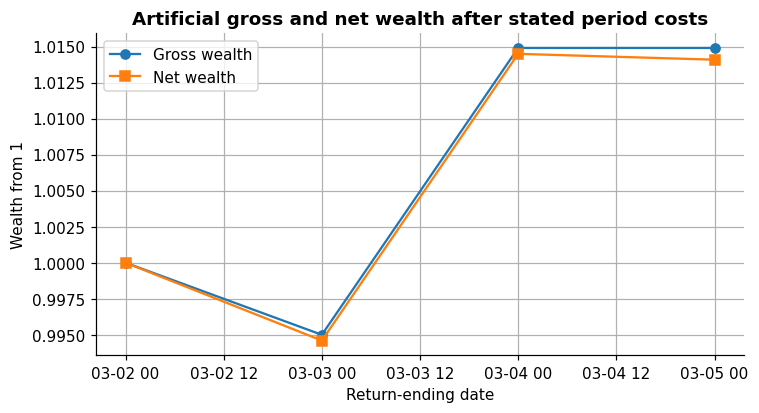

**Figure.** Two artificial wealth lines over four return-ending dates; net wealth falls below gross wealth after the entry and exit charges.

In [23]:
# Purpose: Issue 11 — How do period costs change a compounded wealth path? — calculate the controlled inputs and result.
controlled_wealth_summary = pd.Series(
    {
        "Final gross wealth from initial value 1 (relative units)": controlled_ledger["gross_wealth"].iloc[-1],
        "Final net wealth from initial value 1 (relative units)": controlled_ledger["net_wealth"].iloc[-1],
        "Final wealth difference": controlled_ledger["gross_wealth"].iloc[-1] - controlled_ledger["net_wealth"].iloc[-1],
        "Sum of period cost deductions": controlled_ledger["cost_return_units"].sum(),
    },
    name="Calculated value",
)
display(controlled_wealth_summary.to_frame())
figure, axis = plt.subplots()
axis.plot(controlled_ledger.index, controlled_ledger["gross_wealth"], marker="o", label="Gross wealth")
axis.plot(controlled_ledger.index, controlled_ledger["net_wealth"], marker="s", label="Net wealth")
axis.set_title("Artificial gross and net wealth after stated period costs")
axis.set_xlabel("Return-ending date")
axis.set_ylabel("Wealth from 1")
axis.legend()
show_figure_with_alt_text(figure, "Two artificial wealth lines over four return-ending dates; net wealth falls below gross wealth after the entry and exit charges.")
assert np.isclose(controlled_ledger["gross_wealth"].iloc[-1], 1.0149)
assert np.isclose(controlled_ledger["net_wealth"].iloc[-1], 1.0140862032)

### Interpret Code 1

Final gross wealth is 1.014900 and final net wealth is 1.014086, a difference of approximately 0.000814. The two cost deductions sum to 0.000800, so the values are close but not equal. The first deduction changes the wealth base before the later 2% return, which creates the difference.

### Source-grounded example

Code 2 plots the AAPL candidate's gross and net wealth under the fixed 4-basis-point teaching convention and reports the final values and total cost deductions.

### Before Code 2

Predict whether the source-grounded net-wealth line can cross above the gross-wealth line and whether the final wealth gap equals the sum of period deductions.

,Observed or calculated value
AAPL first return-ending date,2024-01-03
AAPL last return-ending date,2025-01-02
Final gross wealth from 1,1.168361
Final net wealth from 1,1.144331
Final wealth difference,0.02403
Sum of cost deductions,0.0208


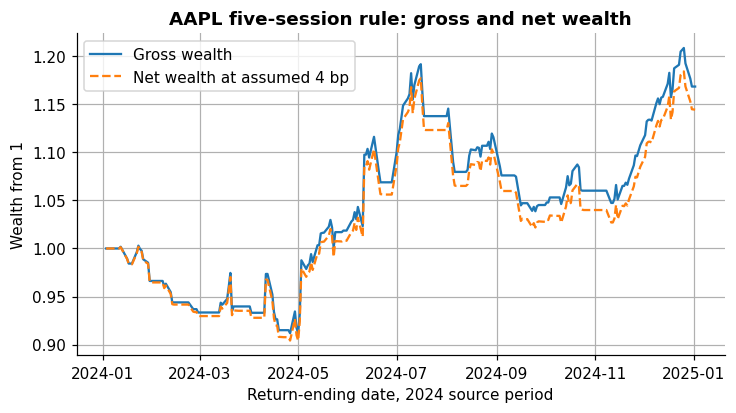

**Figure.** AAPL five-session-rule gross and net wealth from the fixed 2024 request; the net line uses an assumed four-basis-point cost per unit of turnover.

In [24]:
# Purpose: Issue 11 — How do period costs change a compounded wealth path? — evaluate the stated source-derived data.
real_wealth_summary = pd.Series(
    {
        "AAPL first return-ending date": str(real_candidate_ledger.index.min().date()),
        "AAPL last return-ending date": str(real_candidate_ledger.index.max().date()),
        "Final gross wealth from 1": float(real_candidate_ledger["gross_wealth"].iloc[-1]),
        "Final net wealth from 1": float(real_candidate_ledger["net_wealth"].iloc[-1]),
        "Final wealth difference": float(real_candidate_ledger["gross_wealth"].iloc[-1] - real_candidate_ledger["net_wealth"].iloc[-1]),
        "Sum of cost deductions": float(real_candidate_ledger["cost_return_units"].sum()),
    },
    name="Observed or calculated value",
)
display(real_wealth_summary.to_frame())
figure, axis = plt.subplots()
axis.plot(real_candidate_ledger.index, real_candidate_ledger["gross_wealth"], label="Gross wealth")
axis.plot(real_candidate_ledger.index, real_candidate_ledger["net_wealth"], label="Net wealth at assumed 4 bp", linestyle="--")
axis.set_title("AAPL five-session rule: gross and net wealth")
axis.set_xlabel("Return-ending date, 2024 source period")
axis.set_ylabel("Wealth from 1")
axis.legend()
show_figure_with_alt_text(figure, "AAPL five-session-rule gross and net wealth from the fixed 2024 request; the net line uses an assumed four-basis-point cost per unit of turnover.")
assert (real_candidate_ledger["gross_wealth"] + 1e-12 >= real_candidate_ledger["net_wealth"]).all()

### Interpret Code 2

Across 252 AAPL intervals, gross wealth is 1.168361 and net wealth is 1.144331 at 4 basis points. The wealth gap is 0.024030, not the sum of period cost rates 0.020800. Net wealth stays below gross wealth because costs are nonnegative and factors remain positive; the displayed lines do not establish actual execution quality.

### Discussion questions

1. Construct two paths with the same gross returns and the same total cost deductions but place the cost on different dates. Calculate final net wealth and explain why the two endpoints can differ.
2. A report subtracts total turnover times cost from final gross wealth after compounding. Identify the missing timing information and state the row-level calculation needed to verify whether that shortcut is acceptable for its accounting convention.

## Issue 12 — How does an additional execution delay change the held return interval?


An after-close signal cannot earn the return that ended at the same close. Week 4 assumes execution at the next Close and a holding return that ends one further Close later. One additional stored-period delay moves that position one row further:

$$
p_t^{next}=g(s_{t-2}),
\qquad
p_t^{delayed}=g(s_{t-3}).
$$

The delayed result is not obtained by shifting returns while keeping the old dates or turnover. The position, held interval, and every downstream cost must be reconstructed. A delayed strategy may have a higher or lower historical return; delay is an execution assumption, not a directional penalty by definition.


### Connection to documented sources

Investor.gov states that execution takes time and prices can change before an order reaches the market. Nasdaq documents regular market hours, but neither source identifies the fill time of an unspecified strategy. The notebook therefore tests a stated one-row additional delay.

Sources: [Investor.gov on executing an order](https://www.investor.gov/introduction-investing/investing-basics/how-stock-markets-work/executing-order) and [Nasdaq systems hours](https://www.nasdaqtrader.com/content/technicalsupport/nasdaq_sys_hours.pdf).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For the displayed six signals and returns, predict both position sequences, count rows where the positions differ, and state which return each sequence holds on the fourth date.

In [25]:
# Purpose: Issue 12 — How does an additional execution delay change the held return interval? — calculate the controlled inputs and result.
delay_dates = pd.bdate_range("2026-04-01", periods=6)
delay_signal = pd.Series([np.nan, 1.0, 0.0, 1.0, 1.0, 0.0], index=delay_dates, name="After-close signal")
delay_return = pd.Series([0.010, -0.020, 0.015, 0.005, -0.010, 0.020], index=delay_dates, name="Asset return")
position_next = delay_signal.shift(2).fillna(0.0)
position_extra_delay = delay_signal.shift(3).fillna(0.0)
controlled_delay = pd.DataFrame(
    {
        "Signal after close": delay_signal,
        "Asset return": delay_return,
        "Next-Close execution position": position_next,
        "One-extra-period-delay position": position_extra_delay,
        "Next-Close execution gross return": position_next * delay_return,
        "Delayed gross return": position_extra_delay * delay_return,
    }
)
display(controlled_delay.style.format("{:.4f}").set_caption("Artificial signal, return, and execution-delay alignment"))
controlled_delay_summary = pd.Series(
    {
        "Rows with different positions": int((position_next != position_extra_delay).sum()),
        "Next-Close execution final gross wealth": float((1 + controlled_delay["Next-Close execution gross return"]).prod()),
        "Delayed final gross wealth": float((1 + controlled_delay["Delayed gross return"]).prod()),
    },
    name="Calculated value",
)
display(controlled_delay_summary.to_frame())
assert controlled_delay_summary["Rows with different positions"] > 0

,Signal after close,Asset return,Next-Close execution position,One-extra-period-delay position,Next-Close execution gross return,Delayed gross return
2026-04-01 00:00:00,nan,0.0100,0.0000,0.0000,0.0000,0.0000
2026-04-02 00:00:00,1.0000,-0.0200,0.0000,0.0000,-0.0000,-0.0000
2026-04-03 00:00:00,0.0000,0.0150,0.0000,0.0000,0.0000,0.0000
2026-04-06 00:00:00,1.0000,0.0050,1.0000,0.0000,0.0050,0.0000
2026-04-07 00:00:00,1.0000,-0.0100,0.0000,1.0000,-0.0000,-0.0100
2026-04-08 00:00:00,0.0000,0.0200,1.0000,0.0000,0.0200,0.0000


,Calculated value
Rows with different positions,3.0000
Next-Close execution final gross wealth,1.0251
Delayed final gross wealth,0.9900


### Interpret Code 1

Positions differ on 3 of 6 artificial rows. On April 6, the base position is 1 from the April 2 signal; the extra-delayed position is 0. Base gross wealth is 1.025100, versus 0.990000 with the extra delay. This ordering depends on the supplied returns.

### Source-grounded example

Code 2 compares the AAPL five-session signal applied after two stored-row lags with the same signal after three stored-row lags. It recalculates positions before applying source-derived returns.

### Before Code 2

Predict how many AAPL rows have different positions and whether the additional delay must reduce gross final wealth on this source period.

In [26]:
# Purpose: Issue 12 — How does an additional execution delay change the held return interval? — evaluate the stated source-derived data.
real_position_next = source_eval["position_5"]
real_position_delayed = pd.Series(aapl_frame["signal_5"], index=aapl_frame.index).shift(3).fillna(0.0).reindex(source_eval.index)
real_delay_gross = pd.DataFrame(
    {
        "Next-Close execution position": real_position_next,
        "One-extra-period-delay position": real_position_delayed,
        "Asset return": source_eval["asset_return"],
    }
)
real_delay_gross["Next-Close execution gross return"] = real_delay_gross["Next-Close execution position"] * real_delay_gross["Asset return"]
real_delay_gross["Delayed gross return"] = real_delay_gross["One-extra-period-delay position"] * real_delay_gross["Asset return"]
real_delay_summary = pd.Series(
    {
        "Rows with different positions": int((real_position_next != real_position_delayed).sum()),
        "Next-Close execution gross final wealth": float((1 + real_delay_gross["Next-Close execution gross return"]).prod()),
        "Delayed gross final wealth": float((1 + real_delay_gross["Delayed gross return"]).prod()),
    },
    name="Observed value",
)
display(real_delay_summary.to_frame())
assert real_delay_summary["Rows with different positions"] > 0

,Observed value
Rows with different positions,52.000000
Next-Close execution gross final wealth,1.168361
Delayed gross final wealth,1.181313


### Interpret Code 2

The AAPL positions differ on 52 of 252 intervals. Gross wealth is 1.168361 under next-Close execution and 1.181313 after one extra session of delay. Delay raises the endpoint in this sample but is not an execution improvement established from real fills.

### Discussion questions

1. On the controlled fourth date, trace the exact signal date, position, and asset-return interval under both conventions. State whether a signal formed after the third Close can affect either position earning the return ending at the fourth Close.
2. A team delays execution by one row but leaves the original position column unchanged and shifts only the return column. Identify the resulting date mismatch and specify the three columns that must be rebuilt before comparing outcomes.

## Issue 13 — Why must a delayed path recalculate its own turnover and costs?


Turnover belongs to a position path. After execution delay changes $p_t$, its cost must use

$$
\tau_t^{delayed}=|p_t^{delayed}-p_{t-1}^{delayed}|,
$$

not turnover borrowed from the original path. Two paths can have the same number of long observations yet trade on different dates. Charging one path with the other's turnover attaches costs to the wrong decisions and can alter net wealth.


### Connection to documented sources

The financial definition follows the linear trade-cost relation in Lobo, Fazel, and Boyd. Pandas `diff` supplies the row difference but does not choose the correct position series for the analyst.

Sources: [Lobo, Fazel, and Boyd (2007)](https://stanford.edu/~boyd/papers/portfolio.html) and [`pandas.Series.diff`](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

Using the two Issue 12 artificial position paths, predict each total turnover and quantify the delayed path's net-wealth error if it is charged with the original turnover dates.

In [27]:
# Purpose: Issue 13 — Why must a delayed path recalculate its own turnover and costs? — calculate the controlled inputs and result.
turnover_next = one_way_turnover(position_next)
turnover_delayed = one_way_turnover(position_extra_delay)
controlled_correct_delayed_net = position_extra_delay * delay_return - turnover_delayed * 4 / 10_000
controlled_wrong_delayed_net = position_extra_delay * delay_return - turnover_next * 4 / 10_000
controlled_delay_cost_audit = pd.DataFrame(
    {
        "Next-Close execution position": position_next,
        "Next-Close execution turnover": turnover_next,
        "Delayed position": position_extra_delay,
        "Delayed turnover": turnover_delayed,
        "Correct delayed net return": controlled_correct_delayed_net,
        "Delayed net return with borrowed turnover": controlled_wrong_delayed_net,
    }
)
display(controlled_delay_cost_audit.style.format("{:.6f}").set_caption("Artificial delayed path with correct and borrowed turnover"))
controlled_delay_cost_summary = pd.Series(
    {
        "Next-Close execution total turnover": float(turnover_next.sum()),
        "Delayed total turnover": float(turnover_delayed.sum()),
        "Correct delayed final net wealth": float((1 + controlled_correct_delayed_net).prod()),
        "Borrowed-turnover delayed final net wealth": float((1 + controlled_wrong_delayed_net).prod()),
    },
    name="Calculated value",
)
display(controlled_delay_cost_summary.to_frame())
assert not np.allclose(turnover_next, turnover_delayed)

,Next-Close execution position,Next-Close execution turnover,Delayed position,Delayed turnover,Correct delayed net return,Delayed net return with borrowed turnover
2026-04-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-04-02 00:00:00,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000
2026-04-03 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-04-06 00:00:00,1.000000,1.000000,0.000000,0.000000,0.000000,-0.000400
2026-04-07 00:00:00,0.000000,1.000000,1.000000,1.000000,-0.010400,-0.010400
2026-04-08 00:00:00,1.000000,1.000000,0.000000,1.000000,-0.000400,-0.000400


,Calculated value
Next-Close execution total turnover,3.000000
Delayed total turnover,2.000000
Correct delayed final net wealth,0.989204
Borrowed-turnover delayed final net wealth,0.988808


### Interpret Code 1

Base turnover is 3, but the delayed path has turnover 2 because the sample ends before one later instruction can earn a complete interval. Correct delayed wealth is 0.989204; borrowed turnover incorrectly reduces it to 0.988808. Both the total and the dates of charges matter.

### Source-grounded example

Code 2 constructs separate 4-basis-point ledgers for the AAPL next-Close-execution and additional-delay positions, then demonstrates the error from reusing original turnover on the delayed gross returns.

### Before Code 2

Predict whether the two AAPL paths have the same total turnover and whether using borrowed turnover produces the same final net wealth as the correctly recalculated delayed ledger.

In [28]:
# Purpose: Issue 13 — Why must a delayed path recalculate its own turnover and costs? — evaluate the stated source-derived data.
real_next_ledger = cost_ledger(real_position_next, source_eval["asset_return"], TEACHING_TOTAL_ONE_WAY_BP)
real_delayed_ledger = cost_ledger(real_position_delayed, source_eval["asset_return"], TEACHING_TOTAL_ONE_WAY_BP)
borrowed_turnover_delayed_net = real_delayed_ledger["gross_return"] - real_next_ledger["one_way_turnover"] * TEACHING_TOTAL_ONE_WAY_BP / 10_000
real_delay_cost_summary = pd.Series(
    {
        "Next-Close execution total turnover": float(real_next_ledger["one_way_turnover"].sum()),
        "Delayed total turnover": float(real_delayed_ledger["one_way_turnover"].sum()),
        "Correct delayed final net wealth": float(real_delayed_ledger["net_wealth"].iloc[-1]),
        "Borrowed-turnover delayed final net wealth": float((1 + borrowed_turnover_delayed_net).prod()),
        "Rows with different turnover": int((real_next_ledger["one_way_turnover"] != real_delayed_ledger["one_way_turnover"]).sum()),
    },
    name="Observed value",
)
display(real_delay_cost_summary.to_frame())
assert real_delay_cost_summary["Rows with different turnover"] > 0

,Observed value
Next-Close execution total turnover,52.000000
Delayed total turnover,51.000000
Correct delayed final net wealth,1.157432
Borrowed-turnover delayed final net wealth,1.157022
Rows with different turnover,71.000000


### Interpret Code 2

Base turnover is 52 and delayed turnover is 51; charges differ on 71 rows. Correct delayed net wealth is 1.157432, versus 1.157022 with borrowed base turnover. The missing terminal instruction and changed charge dates explain why the original costs cannot be reused.

### Discussion questions

1. Construct two five-row position paths with equal total turnover but changes on different dates. Apply the same return sequence and 8-basis-point rate, then determine whether final net wealth must be equal.
2. A delay table reports only gross-return differences. List the minimum position, turnover, cost, and date evidence needed before deciding whether the delayed implementation has a higher net endpoint.

## Issue 14 — How does a cost-sensitivity grid isolate the cost assumption?


A cost-sensitivity comparison changes the cost rate while keeping data, dates, gross returns, positions, turnover, initial holdings, and terminal rule fixed. For each prespecified rate $b$,

$$
r_t^{net}(b)=r_t^{gross}-\tau_t\frac{b}{10{,}000}.
$$

With nonnegative turnover and positive wealth factors, final net wealth is nonincreasing as $b$ rises. This monotonicity is a calculation check, not evidence that one cost value is realistic. Changing the signal or trading frequency in the same table changes positions and turnover, so the table would no longer isolate the cost rate.


### Connection to documented sources

Patton and Weller show why implementation costs matter for on-paper strategy conclusions. The notebook's grid is a teaching sensitivity calculation and does not estimate the paper's all-in costs.

Sources: [Patton and Weller (2020)](https://doi.org/10.1016/j.jfineco.2020.02.012).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For the Issue 12 next-Close-execution artificial path and cost rates 0, 2, 4, 8, and 12 basis points, predict whether final net wealth can increase as the rate rises.

In [29]:
# Purpose: Issue 14 — How does a cost-sensitivity grid isolate the cost assumption? — calculate the controlled inputs and result.
controlled_cost_grid_bp = [0, 2, 4, 8, 12]
controlled_sensitivity_rows = []
for cost_bp in controlled_cost_grid_bp:
    ledger = cost_ledger(position_next, delay_return, cost_bp)
    controlled_sensitivity_rows.append(
        (cost_bp, float(ledger["one_way_turnover"].sum()), float(ledger["net_wealth"].iloc[-1]))
    )
controlled_cost_sensitivity = pd.DataFrame(
    controlled_sensitivity_rows,
    columns=["One-way cost (basis points)", "Fixed total turnover", "Final net wealth from 1"],
)
display(controlled_cost_sensitivity.style.hide(axis="index").format({"Final net wealth from 1": "{:.6f}"}).set_caption("Artificial cost sensitivity with fixed positions"))
assert controlled_cost_sensitivity["Fixed total turnover"].nunique() == 1
assert controlled_cost_sensitivity["Final net wealth from 1"].is_monotonic_decreasing

One-way cost (basis points),Fixed total turnover,Final net wealth from 1
0,3.000000,1.025100
2,3.000000,1.024490
4,3.000000,1.023880
8,3.000000,1.022662
12,3.000000,1.021444


### Interpret Code 1

Every row keeps total one-way turnover at 3.0. Final net wealth moves from 1.025100 at 0 basis points to 1.021444 at 12 basis points and is monotonically decreasing. The grid identifies sensitivity to the rate only because the position path is unchanged.

### Source-grounded example

Code 2 applies a prespecified 0–20-basis-point grid to fixed AAPL candidate and buy-and-hold positions. Each method recalculates costs from its own fixed turnover, while source dates and gross returns remain unchanged.

### Before Code 2

Predict which method's final wealth is more sensitive to cost from its turnover and whether the two methods must have the same slope.

One-way cost (basis points),Candidate turnover,Candidate final net wealth,Buy-and-hold turnover,Buy-and-hold final net wealth
0,52.000000,1.168361,1.000000,1.313564
2,52.000000,1.156285,1.000000,1.313299
4,52.000000,1.144331,1.000000,1.313035
8,52.000000,1.120786,1.000000,1.312505
12,52.000000,1.097716,1.000000,1.311976
20,52.000000,1.052965,1.000000,1.310917


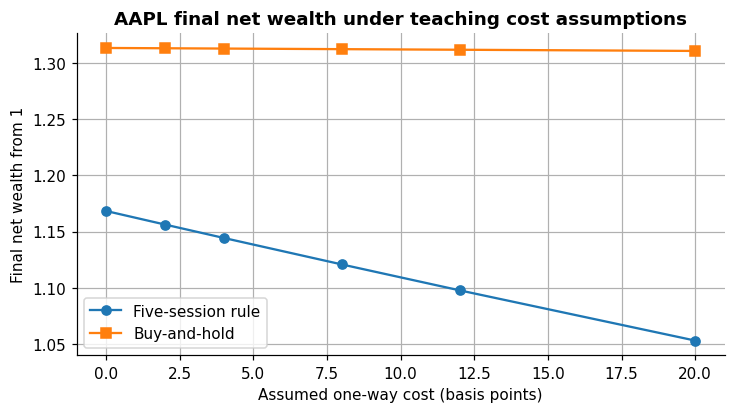

**Figure.** Two AAPL final-net-wealth lines across a zero-to-twenty-basis-point teaching cost grid; positions and source dates remain fixed within each method.

In [30]:
# Purpose: Issue 14 — How does a cost-sensitivity grid isolate the cost assumption? — evaluate the stated source-derived data.
buy_hold_position = pd.Series(1.0, index=source_eval.index)
real_cost_grid_bp = [0, 2, 4, 8, 12, 20]
real_cost_sensitivity_rows = []
for cost_bp in real_cost_grid_bp:
    candidate = cost_ledger(real_position_next, source_eval["asset_return"], cost_bp)
    buy_hold = cost_ledger(buy_hold_position, source_eval["asset_return"], cost_bp)
    real_cost_sensitivity_rows.append(
        (
            cost_bp,
            float(candidate["one_way_turnover"].sum()),
            float(candidate["net_wealth"].iloc[-1]),
            float(buy_hold["one_way_turnover"].sum()),
            float(buy_hold["net_wealth"].iloc[-1]),
        )
    )
real_cost_sensitivity = pd.DataFrame(
    real_cost_sensitivity_rows,
    columns=["One-way cost (basis points)", "Candidate turnover", "Candidate final net wealth", "Buy-and-hold turnover", "Buy-and-hold final net wealth"],
)
display(real_cost_sensitivity.style.hide(axis="index").format({"Candidate final net wealth": "{:.6f}", "Buy-and-hold final net wealth": "{:.6f}"}).set_caption("AAPL cost sensitivity under fixed positions and source dates"))
figure, axis = plt.subplots()
axis.plot(real_cost_sensitivity["One-way cost (basis points)"], real_cost_sensitivity["Candidate final net wealth"], marker="o", label="Five-session rule")
axis.plot(real_cost_sensitivity["One-way cost (basis points)"], real_cost_sensitivity["Buy-and-hold final net wealth"], marker="s", label="Buy-and-hold")
axis.set_title("AAPL final net wealth under teaching cost assumptions")
axis.set_xlabel("Assumed one-way cost (basis points)")
axis.set_ylabel("Final net wealth from 1")
axis.legend()
show_figure_with_alt_text(figure, "Two AAPL final-net-wealth lines across a zero-to-twenty-basis-point teaching cost grid; positions and source dates remain fixed within each method.")
assert real_cost_sensitivity["Candidate final net wealth"].is_monotonic_decreasing
assert real_cost_sensitivity["Buy-and-hold final net wealth"].is_monotonic_decreasing

### Interpret Code 2

Candidate one-way turnover remains 52.0 and buy-and-hold turnover remains 1.0 across all six cost rows. Candidate final wealth changes from 1.168361 at 0 basis points to 1.052965 at 20 basis points; buy-and-hold changes from 1.313564 to 1.310917. The higher-turnover path is more sensitive to the assumed rate, but the table does not identify the rate an investor would actually pay.

### Discussion questions

1. A team changes cost from 2 to 10 basis points and simultaneously changes its signal threshold. Identify why the table no longer isolates cost and specify the columns that must remain identical across rows.
2. Two strategies have total turnover 8 and 40 over the same dates. Without calculating Week 7 metrics, decide whether turnover totals alone determine which terminal wealth has the larger dollar change. Write terminal wealth as a product and identify the missing gross-return path and timing information.

## Issue 15 — What does a break-even transaction cost calculation establish?


For one return interval, candidate A and benchmark B have net returns

$$
r_A^{net}=r_A^{gross}-c\tau_A,
\qquad
r_B^{net}=r_B^{gross}-c\tau_B.
$$

If $\tau_A\ne\tau_B$, the one-period cost rate that makes their net returns equal is

$$
c^*=\frac{r_A^{gross}-r_B^{gross}}{\tau_A-\tau_B}.
$$

A positive $c^*$ has a direct interpretation only under the stated one-period proportional model. Across many periods, costs enter different dates and compound, so a numerical root or prespecified grid is generally needed. If no sign change occurs in the tested range, report that bounded result instead of inventing an exact crossing.


### Connection to documented sources

Investor.gov explicitly asks investors to consider how much an investment must rise before breaking even after fees. Lobo, Fazel, and Boyd provide the linear cost structure used in the one-period derivation.

Sources: [Investor.gov on understanding fees](https://www.investor.gov/introduction-investing/getting-started/understanding-fees) and [Lobo, Fazel, and Boyd (2007)](https://stanford.edu/~boyd/papers/portfolio.html).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For candidate gross return 1.2% with turnover 1 and benchmark gross return 0.8% with turnover 0.20, predict the break-even rate in decimal units and basis points.

In [31]:
# Purpose: Issue 15 — What does a break-even transaction cost calculation establish? — calculate the controlled inputs and result.
candidate_gross = 0.012
benchmark_gross = 0.008
candidate_turnover = 1.0
benchmark_turnover = 0.20
break_even_decimal = (candidate_gross - benchmark_gross) / (candidate_turnover - benchmark_turnover)
break_even_bp = break_even_decimal * 10_000
controlled_break_even = pd.Series(
    {
        "Candidate gross return (percent)": candidate_gross * 100,
        "Candidate turnover": candidate_turnover,
        "Benchmark gross return (percent)": benchmark_gross * 100,
        "Benchmark turnover": benchmark_turnover,
        "Break-even cost (decimal rate per unit turnover)": break_even_decimal,
        "Break-even cost (basis points)": break_even_bp,
        "Candidate net return at break-even (percent)": (candidate_gross - break_even_decimal * candidate_turnover) * 100,
        "Benchmark net return at break-even (percent)": (benchmark_gross - break_even_decimal * benchmark_turnover) * 100,
    },
    name="Calculated value",
)
display(controlled_break_even.to_frame())
assert np.isclose(break_even_bp, 50.0)
assert np.isclose(controlled_break_even["Candidate net return at break-even (percent)"], 0.7)

,Calculated value
Candidate gross return (percent),1.200
Candidate turnover,1.000
Benchmark gross return (percent),0.800
Benchmark turnover,0.200
Break-even cost (decimal rate per unit turnover),0.005
Break-even cost (basis points),50.000
Candidate net return at break-even (percent),0.700
Benchmark net return at break-even (percent),0.700


### Interpret Code 1

The gross-return advantage is 0.40 percentage points and the turnover difference is 0.80. Their ratio is 0.005 in decimal cost per unit turnover, or 50 basis points. At that rate both one-period net returns equal 0.70%. This equality is conditional on the single-period linear model.

### Source-grounded example

Code 2 compares the AAPL five-session and twenty-session rule paths over the same source dates on a prespecified integer grid from 0 through 100 basis points. It reports the first grid interval containing a sign change, or states that none exists.

### Before Code 2

Predict whether the two AAPL rule paths cross within 0–100 basis points and state what may be concluded if no crossing appears.

In [32]:
# Purpose: Issue 15 — What does a break-even transaction cost calculation establish? — evaluate the stated source-derived data.
real_slow_position = source_eval["position_20"]
break_even_grid = np.arange(0.0, 101.0, 1.0)
break_even_rows = []
for cost_bp in break_even_grid:
    fast = cost_ledger(real_position_next, source_eval["asset_return"], cost_bp)
    slow = cost_ledger(real_slow_position, source_eval["asset_return"], cost_bp)
    break_even_rows.append((cost_bp, float(fast["net_wealth"].iloc[-1]), float(slow["net_wealth"].iloc[-1])))
real_break_even_grid = pd.DataFrame(break_even_rows, columns=["One-way cost (basis points)", "Five-session final net wealth", "Twenty-session final net wealth"])
real_break_even_grid["Difference: five minus twenty"] = real_break_even_grid["Five-session final net wealth"] - real_break_even_grid["Twenty-session final net wealth"]
sign_product = real_break_even_grid["Difference: five minus twenty"] * real_break_even_grid["Difference: five minus twenty"].shift(1)
crossing_rows = real_break_even_grid.index[sign_product <= 0].tolist()
if crossing_rows:
    crossing_index = crossing_rows[0]
    crossing_statement = f"First tested sign change lies between {int(real_break_even_grid.loc[crossing_index - 1, 'One-way cost (basis points)'])} and {int(real_break_even_grid.loc[crossing_index, 'One-way cost (basis points)'])} basis points."
else:
    crossing_statement = "No sign change appears from 0 through 100 basis points."
real_break_even_output = pd.concat([real_break_even_grid.head(3), real_break_even_grid.tail(3)])
display(real_break_even_output.style.hide(axis="index").format({"Five-session final net wealth": "{:.6f}", "Twenty-session final net wealth": "{:.6f}", "Difference: five minus twenty": "{:.6f}"}).set_caption("Selected rows from the prespecified AAPL break-even grid"))
print(crossing_statement)
assert len(real_break_even_grid) == 101

One-way cost (basis points),Five-session final net wealth,Twenty-session final net wealth,Difference: five minus twenty
0.000000,1.168361,1.139734,0.028627
1.000000,1.162308,1.137117,0.025191
2.000000,1.156285,1.134505,0.021780
98.000000,0.700503,0.908791,-0.208288
99.000000,0.696837,0.906683,-0.209846
100.000000,0.693191,0.904580,-0.211389


First tested sign change lies between 8 and 9 basis points.


### Interpret Code 2

At zero cost, five-session minus twenty-session wealth is +0.028627; at 100 basis points it is −0.211389. The first grid sign change is between 8 and 9 basis points. That brackets a crossing under this additive model; it neither identifies an exact root nor estimates an investor's real cost.

### Discussion questions

1. In the controlled formula, set candidate and benchmark turnover equal while leaving gross returns different. Explain why the denominator becomes zero and state the correct conclusion about cost-based break-even under that one-period model.
2. A multi-period grid changes sign between 7 and 8 basis points. State the narrow conclusion supported by the grid, the additional numerical step needed for a more precise root, and why neither result proves which real-world cost applies.

## Issue 16 — What question does a cash benchmark answer?


A cash benchmark asks what happened when the risky position was not taken under a stated cash-return assumption. If periodic cash return is $r_t^{cash}$, its wealth is

$$
W_T^{cash}=\prod_{t=1}^{T}(1+r_t^{cash}).
$$

Setting cash return to zero produces wealth 1 and must be stated as an assumption. A nonzero cash or risk-free series requires its own source, frequency, date alignment, and availability rule. Cash answers whether the tested risky decision added value relative to not taking that exposure; it does not match the candidate's market exposure or risk.


### Connection to documented sources

The Report 1 instructions require transparent financial benchmarks under common dates and stated assumptions. The common course cash-return input is still pending, so the notebook demonstrates zero and artificial nonzero cash assumptions separately.

Sources: the [Report 1 instructions](week10_main.md).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

Using the four Issue 10 intervals, predict cash wealth under a zero periodic return and under an artificial 0.01% periodic return, then compare both with candidate net wealth.

In [33]:
# Purpose: Issue 16 — What question does a cash benchmark answer? — calculate the controlled inputs and result.
controlled_cash = pd.DataFrame(index=controlled_ledger.index)
controlled_cash["Zero cash return"] = 0.0
controlled_cash["Artificial cash return of 0.01% per interval"] = 0.0001
controlled_cash_summary = pd.Series(
    {
        "Candidate final net wealth": float(controlled_ledger["net_wealth"].iloc[-1]),
        "Zero-return cash final wealth": float((1 + controlled_cash["Zero cash return"]).prod()),
        "Artificial nonzero cash final wealth": float((1 + controlled_cash["Artificial cash return of 0.01% per interval"]).prod()),
    },
    name="Calculated value",
)
display(controlled_cash_summary.to_frame())
assert np.isclose(controlled_cash_summary["Zero-return cash final wealth"], 1.0)

,Calculated value
Candidate final net wealth,1.014086
Zero-return cash final wealth,1.000000
Artificial nonzero cash final wealth,1.000400


### Interpret Code 1

Candidate net wealth is 1.014086. Zero-return cash remains 1.000000, while the artificial 0.01% per-interval assumption compounds to approximately 1.000400. Changing the cash assumption changes the comparison even though the candidate path is unchanged.

### Source-grounded example

Code 2 compares the AAPL candidate with cash over identical source dates under zero and artificial 1-basis-point-per-interval cash returns. The nonzero cash rate is not a sourced interest-rate series.

### Before Code 2

Predict which cash assumption has the higher endpoint and state whether either endpoint changes the AAPL candidate's own net ledger.

In [34]:
# Purpose: Issue 16 — What question does a cash benchmark answer? — evaluate the stated source-derived data.
real_cash_summary = pd.Series(
    {
        "Common return intervals": len(real_candidate_ledger),
        "AAPL candidate final net wealth at assumed 4 bp": float(real_candidate_ledger["net_wealth"].iloc[-1]),
        "Zero-return cash final wealth": 1.0,
        "Artificial cash return per interval (basis points)": 1.0,
        "Artificial nonzero cash final wealth": float((1 + pd.Series(0.0001, index=real_candidate_ledger.index)).prod()),
    },
    name="Observed, assumed, or calculated value",
)
display(real_cash_summary.to_frame())
assert real_cash_summary["Artificial nonzero cash final wealth"] > 1.0

,"Observed, assumed, or calculated value"
Common return intervals,252.000000
AAPL candidate final net wealth at assumed 4 bp,1.144331
Zero-return cash final wealth,1.000000
Artificial cash return per interval (basis points),1.000000
Artificial nonzero cash final wealth,1.025519


### Interpret Code 2

Over 252 common AAPL return intervals, zero-return cash ends at 1.000000 and the artificial 1-basis-point-per-interval cash path ends at 1.025519. The candidate endpoint remains 1.144331 because its ledger is not changed. Neither cash assumption is the approved course rate, and no risk comparison is made before Week 7.

### Discussion questions

1. A team compares daily strategy returns with an annual cash rate by subtracting the annual number on every row. Identify the unit mismatch and specify the source, compounding, frequency, and date information required before constructing the cash series.
2. The candidate ends above zero-return cash but below a sourced interest-bearing cash benchmark. State the two narrow conclusions and explain why neither establishes risk-adjusted superiority without Week 7 evidence.

## Issue 17 — What question does a buy-and-hold benchmark answer?


Buy-and-hold asks whether timing improved on continuous exposure to the same asset over the same return intervals. Starting from cash, a fully invested buy-and-hold position has initial turnover 1 and then no turnover unless the design imposes liquidation or another trade.

The candidate and benchmark must use the same asset returns, evaluation dates, one-way cost rate, initial-position convention, and terminal rule. They need not have equal turnover or exposure; those differences are part of what the benchmark reveals. Comparing the endpoints alone does not control risk or statistical uncertainty.


### Connection to documented sources

The Report 1 requirements include buy-and-hold as a financial benchmark. Patton and Weller support evaluating on-paper returns after implementation costs, but Week 6's benchmark is a simplified historical calculation.

Sources: the [Report 1 instructions](week10_main.md) and [Patton and Weller (2020)](https://doi.org/10.1016/j.jfineco.2020.02.012).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For the Issue 10 artificial asset returns, predict buy-and-hold turnover, final net wealth at 4 basis points, and whether it uses the same gross return as the timing candidate on the first cash row.

In [35]:
# Purpose: Issue 17 — What question does a buy-and-hold benchmark answer? — calculate the controlled inputs and result.
controlled_buy_hold_position = pd.Series(1.0, index=controlled_return.index)
controlled_buy_hold_ledger = cost_ledger(controlled_buy_hold_position, controlled_return, 4.0)
controlled_buy_hold_comparison = pd.DataFrame(
    [
        ("Timing candidate", controlled_ledger["one_way_turnover"].sum(), controlled_ledger["gross_wealth"].iloc[-1], controlled_ledger["net_wealth"].iloc[-1]),
        ("Buy-and-hold", controlled_buy_hold_ledger["one_way_turnover"].sum(), controlled_buy_hold_ledger["gross_wealth"].iloc[-1], controlled_buy_hold_ledger["net_wealth"].iloc[-1]),
    ],
    columns=["Method", "Total one-way turnover", "Final gross wealth", "Final net wealth"],
)
display(controlled_buy_hold_comparison.style.hide(axis="index").format({"Final gross wealth": "{:.6f}", "Final net wealth": "{:.6f}"}).set_caption("Artificial timing and buy-and-hold comparison"))
assert np.isclose(controlled_buy_hold_ledger["one_way_turnover"].sum(), 1.0)

Method,Total one-way turnover,Final gross wealth,Final net wealth
Timing candidate,2.000000,1.014900,1.014086
Buy-and-hold,1.000000,1.014799,1.014397


### Interpret Code 1

Buy-and-hold one-way turnover is 1 because it enters once from cash and remains invested. Its gross final wealth is 1.014799 and net final wealth is 1.014397. The timing candidate has turnover 2 and net wealth 1.014086. The methods do not earn the same first-row gross return because the candidate remains in cash while buy-and-hold is invested.

### Source-grounded example

Code 2 compares the AAPL five-session rule with AAPL buy-and-hold on identical return-ending dates and the same assumed 4-basis-point one-way rate, with no terminal liquidation.

### Before Code 2

Predict each method's total turnover and which has the higher final net wealth in the fixed AAPL source period.

Method,Common return intervals,Total one-way turnover,Final gross wealth,Final net wealth
Five-session rule,252,52.000000,1.168361,1.144331
Buy-and-hold,252,1.000000,1.313564,1.313035


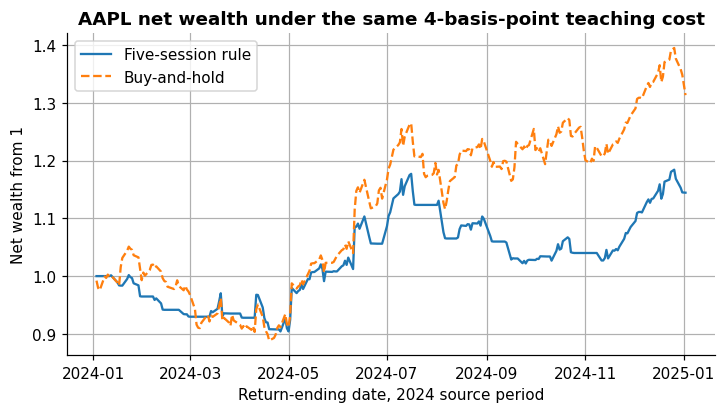

**Figure.** AAPL five-session-rule and buy-and-hold net wealth over identical source dates with the same assumed four-basis-point one-way cost and no terminal liquidation.

In [36]:
# Purpose: Issue 17 — What question does a buy-and-hold benchmark answer? — evaluate the stated source-derived data.
real_buy_hold_ledger = cost_ledger(buy_hold_position, source_eval["asset_return"], TEACHING_TOTAL_ONE_WAY_BP)
real_buy_hold_comparison = pd.DataFrame(
    [
        ("Five-session rule", len(real_candidate_ledger), real_candidate_ledger["one_way_turnover"].sum(), real_candidate_ledger["gross_wealth"].iloc[-1], real_candidate_ledger["net_wealth"].iloc[-1]),
        ("Buy-and-hold", len(real_buy_hold_ledger), real_buy_hold_ledger["one_way_turnover"].sum(), real_buy_hold_ledger["gross_wealth"].iloc[-1], real_buy_hold_ledger["net_wealth"].iloc[-1]),
    ],
    columns=["Method", "Common return intervals", "Total one-way turnover", "Final gross wealth", "Final net wealth"],
)
display(real_buy_hold_comparison.style.hide(axis="index").format({"Final gross wealth": "{:.6f}", "Final net wealth": "{:.6f}"}).set_caption("AAPL timing and buy-and-hold under common source dates and assumed cost"))
figure, axis = plt.subplots()
axis.plot(real_candidate_ledger.index, real_candidate_ledger["net_wealth"], label="Five-session rule")
axis.plot(real_buy_hold_ledger.index, real_buy_hold_ledger["net_wealth"], label="Buy-and-hold", linestyle="--")
axis.set_title("AAPL net wealth under the same 4-basis-point teaching cost")
axis.set_xlabel("Return-ending date, 2024 source period")
axis.set_ylabel("Net wealth from 1")
axis.legend()
show_figure_with_alt_text(figure, "AAPL five-session-rule and buy-and-hold net wealth over identical source dates with the same assumed four-basis-point one-way cost and no terminal liquidation.")
assert real_buy_hold_comparison["Common return intervals"].nunique() == 1

### Interpret Code 2

Both AAPL methods use 252 source-derived close-to-close price-return intervals. The five-session rule has total one-way turnover of 52.0 and final net wealth of 1.144331; buy-and-hold has turnover 1.0 and final net wealth of 1.313035. Cash dividends are not added, so this is not a total-return comparison. The historical endpoint comparison also does not show whether either method had preferable risk, drawdown, or statistical reliability.

### Discussion questions

1. A candidate trades AAPL but its buy-and-hold benchmark uses SPY. Identify which comparison condition fails and state two different financial questions that the AAPL and SPY benchmarks would answer.
2. The candidate is in cash for half the period and has a shallower loss than buy-and-hold. Determine which exposure evidence is needed before attributing the difference to timing skill rather than lower market participation.

## Issue 18 — What question does a rule-based benchmark answer?


A rule-based benchmark asks whether a more complex candidate improved on a prespecified, reproducible decision rule. The benchmark must define its feature, threshold, information time, position lag, and rebalance frequency before evaluation. Both paths then use the same asset returns, dates, execution convention, and cost model.

Week 6 uses five-session and twenty-session trailing-momentum rules only to demonstrate the comparison. Neither is an AI model. For Report 1, the candidate must come from the team's required prediction model, and the rule-based or statistical prediction serves as the prediction baseline. Model complexity alone does not make the candidate preferable.


### Connection to documented sources

The Report 1 instructions require a prediction model and a rule-based or statistical prediction baseline on the same target dates. Week 6 connects those earlier predictions to cost-adjusted positions without redefining the report rubric.

Sources: the [Report 1 instructions](week10_main.md).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For the supplied artificial candidate and rule positions, predict each total turnover and final net wealth at 4 basis points, then identify the condition changed between the methods.

In [37]:
# Purpose: Issue 18 — What question does a rule-based benchmark answer? — calculate the controlled inputs and result.
benchmark_dates = pd.bdate_range("2026-05-04", periods=8)
benchmark_return = pd.Series([0.010, -0.006, 0.012, 0.004, -0.008, 0.015, -0.003, 0.009], index=benchmark_dates)
candidate_position_artificial = pd.Series([0, 1, 1, 0, 1, 1, 0, 1], index=benchmark_dates, dtype=float)
rule_position_artificial = pd.Series([0, 0, 1, 1, 1, 0, 0, 1], index=benchmark_dates, dtype=float)
candidate_artificial_ledger = cost_ledger(candidate_position_artificial, benchmark_return, 4.0)
rule_artificial_ledger = cost_ledger(rule_position_artificial, benchmark_return, 4.0)
controlled_rule_comparison = pd.DataFrame(
    [
        ("Supplied candidate position", candidate_artificial_ledger["one_way_turnover"].sum(), candidate_artificial_ledger["net_wealth"].iloc[-1]),
        ("Supplied rule-based benchmark", rule_artificial_ledger["one_way_turnover"].sum(), rule_artificial_ledger["net_wealth"].iloc[-1]),
    ],
    columns=["Method", "Total one-way turnover", "Final net wealth"],
)
display(controlled_rule_comparison.style.hide(axis="index").format({"Final net wealth": "{:.6f}"}).set_caption("Artificial candidate and rule-based benchmark positions"))
assert candidate_artificial_ledger.index.equals(rule_artificial_ledger.index)

Method,Total one-way turnover,Final net wealth
Supplied candidate position,5.000000,1.019920
Supplied rule-based benchmark,3.000000,1.015779


### Interpret Code 1

The supplied candidate has total one-way turnover of 5.0 and final net wealth of 1.019920. The rule-based benchmark has turnover 3.0 and final net wealth 1.015779. Data, dates, returns, lag, and the 4-basis-point rate are held fixed; only the supplied position rule changes.

### Source-grounded example

Code 2 compares AAPL five-session and twenty-session trailing-momentum rules on the same source dates, lag, and 4-basis-point teaching cost. The lookback is the changing method input.

### Before Code 2

Predict which AAPL rule has higher turnover and whether the lower-turnover rule must have higher final net wealth.

In [38]:
# Purpose: Issue 18 — What question does a rule-based benchmark answer? — evaluate the stated source-derived data.
real_slow_ledger = cost_ledger(real_slow_position, source_eval["asset_return"], TEACHING_TOTAL_ONE_WAY_BP)
real_rule_comparison = pd.DataFrame(
    [
        ("Five-session momentum rule", 5, len(real_candidate_ledger), real_candidate_ledger["one_way_turnover"].sum(), real_candidate_ledger["net_wealth"].iloc[-1]),
        ("Twenty-session momentum rule", 20, len(real_slow_ledger), real_slow_ledger["one_way_turnover"].sum(), real_slow_ledger["net_wealth"].iloc[-1]),
    ],
    columns=["Method", "Trailing lookback (stored sessions)", "Common return intervals", "Total one-way turnover", "Final net wealth"],
)
display(real_rule_comparison.style.hide(axis="index").format({"Final net wealth": "{:.6f}"}).set_caption("AAPL rule-based benchmarks under common source dates and assumed cost"))
assert real_rule_comparison["Common return intervals"].nunique() == 1

Method,Trailing lookback (stored sessions),Common return intervals,Total one-way turnover,Final net wealth
Five-session momentum rule,5,252,52.000000,1.144331
Twenty-session momentum rule,20,252,23.000000,1.129298


### Interpret Code 2

Both AAPL rules use 252 return intervals. The five-session rule has total one-way turnover of 52.0 and final net wealth of 1.144331; the twenty-session rule has turnover 23.0 and final net wealth of 1.129298. The lower-turnover rule does not automatically have the higher endpoint because the two rules also hold different source-derived returns.

### Discussion questions

1. A team chooses its rule benchmark after seeing which lookback gives the weakest test result. Identify the selection problem and specify when the benchmark definition must be frozen for a defensible Report 1 comparison.
2. The complex candidate and rule-based benchmark have equal final net wealth, but the candidate trades twice as much. State what Week 6 can conclude and which Week 7 evidence is still needed before making a broader decision.

## Issue 19 — How is an equal-weighted benchmark compared under common multi-asset conditions?


For $N$ assets, an equal-weighted benchmark assigns $w_j^{EW}=1/N$. On one common holding interval with aligned asset returns $R_j$, portfolio gross return is

$$
r^{gross}=\sum_{j=1}^{N}w_jR_j.
$$

Candidate and benchmark must use the same asset universe, return endpoints, currency treatment, execution time, and cost convention. Starting from cash, any long-only fully invested weight vector has one-way entry turnover $\sum_j|w_j-0|=1$. A one-interval comparison demonstrates compatible accounting; Week 8 develops multi-period weighting, weight drift, and rebalancing.


### Connection to documented sources

DeMiguel, Garlappi, and Uppal formally study the 1/N strategy as a portfolio benchmark. Week 6 uses equal weighting only for common-condition cost accounting and does not reproduce their empirical study or compare optimization methods.

Sources: [DeMiguel, Garlappi, and Uppal (2009)](https://doi.org/10.1093/rfs/hhm075).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For asset returns 2.0% and -1.0%, candidate weights 0.75/0.25, equal weights 0.50/0.50, and a common 4-basis-point entry cost, predict both gross and net returns.

In [39]:
# Purpose: Issue 19 — How is an equal-weighted benchmark compared under common multi-asset conditions? — calculate the controlled inputs and result.
controlled_asset_returns = pd.Series({"Asset A": 0.020, "Asset B": -0.010})
controlled_weights = pd.DataFrame(
    {
        "Candidate": [0.75, 0.25],
        "Equal-weighted": [0.50, 0.50],
    },
    index=controlled_asset_returns.index,
)
controlled_multi_rows = []
for method in controlled_weights.columns:
    weight = controlled_weights[method]
    gross = float(weight @ controlled_asset_returns)
    turnover = float(weight.abs().sum())
    cost = turnover * 4 / 10_000
    controlled_multi_rows.append((method, weight.sum(), turnover, gross, cost, gross - cost))
controlled_multiasset = pd.DataFrame(controlled_multi_rows, columns=["Method", "Weight sum", "Entry turnover", "Gross return", "Cost deduction", "Net return"])
display(controlled_weights.style.format("{:.2f}").set_caption("Artificial candidate and equal weights"))
display(controlled_multiasset.style.hide(axis="index").format({"Gross return": "{:.4%}", "Cost deduction": "{:.4%}", "Net return": "{:.4%}"}).set_caption("One-interval artificial portfolio comparison"))
assert np.allclose(controlled_multiasset["Weight sum"], 1.0)

,Candidate,Equal-weighted
Asset A,0.75,0.50
Asset B,0.25,0.50


Method,Weight sum,Entry turnover,Gross return,Cost deduction,Net return
Candidate,1.000000,1.000000,1.2500%,0.0400%,1.2100%
Equal-weighted,1.000000,1.000000,0.5000%,0.0400%,0.4600%


### Interpret Code 1

The candidate gross return is 1.25% and net return is 1.21%. Equal weighting has gross return 0.50% and net return 0.46%. Both enter from cash with turnover 1 and deduct 0.04%; the difference therefore comes from the supplied weights applied to the same two returns.

### Source-grounded example

Code 2 applies supplied 70/30 and equal 50/50 weights to the first common AAPL/MSFT return interval. Returns are source-derived; weights and the 4-basis-point entry cost are instructor-created.

### Before Code 2

Predict both net returns from the displayed source-derived asset returns and decide whether the one interval can establish a generally preferable weighting method.

In [40]:
# Purpose: Issue 19 — How is an equal-weighted benchmark compared under common multi-asset conditions? — evaluate the stated source-derived data.
multi_date = source_returns.index[0]
multi_returns = source_returns.loc[multi_date, ["AAPL", "MSFT"]]
real_weights = pd.DataFrame(
    {
        "Supplied 70/30 candidate": [0.70, 0.30],
        "Equal-weighted benchmark": [0.50, 0.50],
    },
    index=["AAPL", "MSFT"],
)
real_multi_rows = []
for method in real_weights.columns:
    weight = real_weights[method]
    gross = float(weight @ multi_returns)
    turnover = float(weight.abs().sum())
    cost = turnover * TEACHING_TOTAL_ONE_WAY_BP / 10_000
    real_multi_rows.append((method, str(multi_date.date()), turnover, gross, cost, gross - cost))
real_multiasset = pd.DataFrame(real_multi_rows, columns=["Method", "Return-ending date", "Entry turnover", "Gross return", "Assumed cost deduction", "Net return"])
display(multi_returns.rename("Source-derived return (decimal)").to_frame())
display(real_weights.style.format("{:.2f}").set_caption("Instructor-supplied AAPL/MSFT weights"))
display(real_multiasset.style.hide(axis="index").format({"Gross return": "{:.6f}", "Assumed cost deduction": "{:.6f}", "Net return": "{:.6f}"}).set_caption("AAPL/MSFT one-interval comparison with a common assumed cost"))
assert np.allclose(real_weights.sum(), 1.0)
assert np.allclose(real_multiasset["Entry turnover"], 1.0)

,Source-derived return (decimal)
AAPL,-0.007488
MSFT,-0.000728


,Supplied 70/30 candidate,Equal-weighted benchmark
AAPL,0.70,0.50
MSFT,0.30,0.50


Method,Return-ending date,Entry turnover,Gross return,Assumed cost deduction,Net return
Supplied 70/30 candidate,2024-01-03,1.000000,-0.005460,0.000400,-0.005860
Equal-weighted benchmark,2024-01-03,1.000000,-0.004108,0.000400,-0.004508


### Interpret Code 2

On the return interval ending 2024-01-03, source-derived AAPL and MSFT returns are -0.007488 and -0.000728, respectively. The supplied 70/30 portfolio has gross return -0.005460 and net return -0.005860; equal weighting has gross return -0.004108 and net return -0.004508. Both deduct 0.0004 because entry turnover is 1. One interval cannot establish which weighting method is generally preferable.

### Discussion questions

1. A candidate uses AAPL/MSFT while its equal-weighted benchmark adds NVDA. Identify why the return difference cannot be attributed only to weights and specify the common universe needed for the comparison.
2. After the controlled interval, asset prices move and the candidate and equal-weighted holdings drift. List the additional holdings, trade, and cost records required for a second-period comparison without silently restoring target weights.

## Issue 20 — What can the integrated net-backtest evidence support before Week 7?


An integrated Week 6 table may compare final net wealth, total one-way turnover, cost deductions, and position-change counts when every method uses compatible source dates, return fields, execution timing, cost rules, initial holdings, and terminal treatment.

The table can state how the methods differed on those quantities in the tested period. It cannot establish risk-adjusted superiority, drawdown control, statistical reliability, freedom from repeated selection, or future performance. Those claims require the Week 7 measures, uncertainty analysis, selection record, and audit.


### Connection to documented sources

Patton and Weller support distinguishing on-paper from cost-adjusted evidence. The course Report 1 instructions require traceable prediction, backtest, cost, benchmark, and limitation evidence; this issue supplies the Week 6 portion only.

Sources: [Patton and Weller (2020)](https://doi.org/10.1016/j.jfineco.2020.02.012) and the [Report 1 instructions](week10_main.md).

### Controlled example

This first example uses instructor-created values. Its output supports only the displayed calculation under the stated cost and execution assumptions.

### Before Code 1

For the eight artificial returns from Issue 18, predict the ordering of final net wealth for cash, buy-and-hold, the supplied candidate, and the rule-based benchmark, and identify at least three claims the endpoints cannot support.

In [41]:
# Purpose: Issue 20 — What can the integrated net-backtest evidence support before Week 7? — calculate the controlled inputs and result.
integrated_artificial_methods = {
    "Cash": pd.Series(0.0, index=benchmark_dates),
    "Buy-and-hold": pd.Series(1.0, index=benchmark_dates),
    "Supplied candidate": candidate_position_artificial,
    "Rule-based benchmark": rule_position_artificial,
}
integrated_artificial_rows = []
for method, position in integrated_artificial_methods.items():
    if method == "Cash":
        ledger = cost_ledger(position, benchmark_return, 0.0)
    else:
        ledger = cost_ledger(position, benchmark_return, 4.0)
    integrated_artificial_rows.append(
        (
            method,
            len(ledger),
            float(ledger["one_way_turnover"].sum()),
            int((ledger["one_way_turnover"] > 0).sum()),
            float(ledger["cost_return_units"].sum()),
            float(ledger["net_wealth"].iloc[-1]),
        )
    )
integrated_artificial = pd.DataFrame(integrated_artificial_rows, columns=["Method", "Common intervals", "Total one-way turnover", "Cost-bearing rows", "Sum of cost deductions", "Final net wealth"])
display(integrated_artificial.sort_values("Final net wealth", ascending=False).style.hide(axis="index").format({"Sum of cost deductions": "{:.6f}", "Final net wealth": "{:.6f}"}).set_caption("Integrated artificial Week 6 comparison"))
assert integrated_artificial["Common intervals"].nunique() == 1

Method,Common intervals,Total one-way turnover,Cost-bearing rows,Sum of cost deductions,Final net wealth
Buy-and-hold,8,1.000000,1,0.000400,1.032795
Supplied candidate,8,5.000000,5,0.002000,1.019920
Rule-based benchmark,8,3.000000,3,0.001200,1.015779
Cash,8,0.000000,0,0.000000,1.000000


### Interpret Code 1

All four artificial methods use 8 intervals. From highest to lowest final net wealth, the displayed ordering is buy-and-hold, supplied candidate, rule-based benchmark, and cash. Turnover, cost-bearing rows, and cost sums remain visible beside the endpoint. The table does not contain volatility, drawdown, uncertainty, attempted-model counts, or later-period evidence, so none of those conclusions is supported.

### Source-grounded example

Code 2 compares cash, AAPL buy-and-hold, and the two AAPL rule-based timing benchmarks over identical source-derived return dates. Noncash methods use the same 4-basis-point teaching rate and no terminal liquidation.

### Before Code 2

Predict the final-net-wealth ordering and identify which method has the highest turnover before running the integrated AAPL table.

Method,Common return intervals,Total one-way turnover,Cost-bearing rows,Sum of cost deductions,Final net wealth
AAPL buy-and-hold,252,1.000000,1,0.000400,1.313035
AAPL five-session rule,252,52.000000,52,0.020800,1.144331
AAPL twenty-session rule,252,23.000000,23,0.009200,1.129298
Cash at assumed zero return,252,0.000000,0,0.000000,1.000000


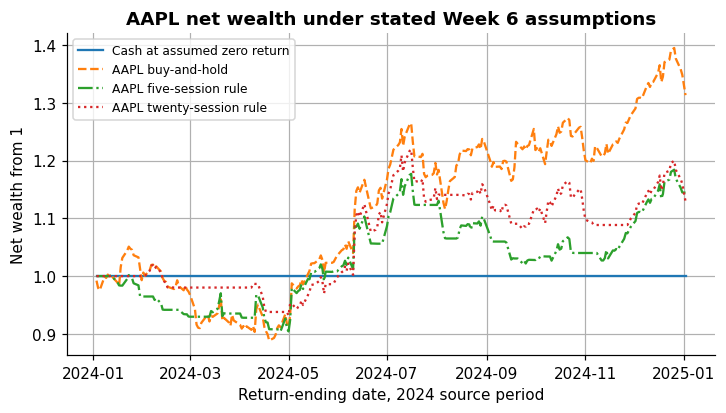

**Figure.** Cash, AAPL buy-and-hold, five-session-rule, and twenty-session-rule net wealth on common 2024 source dates; noncash methods use the same assumed four-basis-point cost.

In [42]:
# Purpose: Issue 20 — What can the integrated net-backtest evidence support before Week 7? — evaluate the stated source-derived data.
real_integrated_methods = {
    "Cash at assumed zero return": (pd.Series(0.0, index=source_eval.index), 0.0),
    "AAPL buy-and-hold": (buy_hold_position, TEACHING_TOTAL_ONE_WAY_BP),
    "AAPL five-session rule": (real_position_next, TEACHING_TOTAL_ONE_WAY_BP),
    "AAPL twenty-session rule": (real_slow_position, TEACHING_TOTAL_ONE_WAY_BP),
}
real_integrated_rows = []
real_integrated_paths = {}
for method, (position, cost_bp) in real_integrated_methods.items():
    ledger = cost_ledger(position, source_eval["asset_return"], cost_bp)
    real_integrated_paths[method] = ledger["net_wealth"]
    real_integrated_rows.append(
        (
            method,
            len(ledger),
            float(ledger["one_way_turnover"].sum()),
            int((ledger["one_way_turnover"] > 0).sum()),
            float(ledger["cost_return_units"].sum()),
            float(ledger["net_wealth"].iloc[-1]),
        )
    )
real_integrated = pd.DataFrame(real_integrated_rows, columns=["Method", "Common return intervals", "Total one-way turnover", "Cost-bearing rows", "Sum of cost deductions", "Final net wealth"])
display(real_integrated.sort_values("Final net wealth", ascending=False).style.hide(axis="index").format({"Sum of cost deductions": "{:.6f}", "Final net wealth": "{:.6f}"}).set_caption("AAPL Week 6 common-condition comparison"))
figure, axis = plt.subplots()
for (method, path), style in zip(real_integrated_paths.items(), ['-', '--', '-.', ':']):
    axis.plot(path.index, path, label=method, linestyle=style)
axis.set_title("AAPL net wealth under stated Week 6 assumptions")
axis.set_xlabel("Return-ending date, 2024 source period")
axis.set_ylabel("Net wealth from 1")
axis.legend(fontsize=8)
show_figure_with_alt_text(figure, "Cash, AAPL buy-and-hold, five-session-rule, and twenty-session-rule net wealth on common 2024 source dates; noncash methods use the same assumed four-basis-point cost.")
assert real_integrated["Common return intervals"].nunique() == 1

### Interpret Code 2

All four methods use 252 common close-to-close price-return intervals. From highest to lowest final net wealth, the ordering is AAPL buy-and-hold, the AAPL five-session rule, the AAPL twenty-session rule, and cash at an assumed zero return. The AAPL five-session rule has the highest total one-way turnover at 52.0. These results are conditional on the fixed AAPL request, exclusion of cash dividends, rule definitions, zero cash return, no terminal liquidation, and assumed cost. Week 7 is still required before discussing volatility, drawdown, uncertainty, or selection risk.

### Discussion questions

1. Choose the top endpoint in the controlled table. Write one conclusion supported by the common-condition evidence and four claims that must wait for Week 7, naming the missing measure or record for each.
2. A team reports only its best net endpoint and omits the other models and thresholds tried. Explain why the Week 6 accounting may still be correct but the research conclusion remains incomplete, and identify the Week 7 selection evidence required.

# Independent practice issues

The first three exercises isolate unit conversion, turnover, and execution delay. Case 4 combines the complete Week 6 ledger and benchmark comparison. Starter cells load the required artificial inputs but do not calculate the requested answers. Complete only the submissions designated by the instructor.

## Practice issue 1 — Repair incompatible transaction-cost units

The input table mixes a USD fixed commission, a full spread in basis points, slippage in percent, and portfolio turnover. Convert every applicable component into both US dollars and decimal return units for a USD 25,000 portfolio. State whether the fixed commission depends on turnover, convert the full spread to a one-way half-spread, and identify one value that cannot be called measured.

Required checks: basis points are divided by 10,000 exactly once; 0.03% becomes 3 basis points; fixed and proportional fees retain separate formulas; and every amount has a unit and evidence status.

### Discussion questions

1. If portfolio value increases to USD 250,000 while the trade and fee assumptions remain fixed, identify which dollar costs and return-rate deductions change.
2. The slippage row has no order or fill record. Decide whether it belongs in a reproducible sensitivity analysis and whether it may be described as realized execution evidence.

In [43]:
# Purpose: Issue 20 — What can the integrated net-backtest evidence support before Week 7? — evaluate the stated source-derived data.
practice_1 = pd.DataFrame(
    [
        ("Fixed commission", 2.00, "USD per charged order", "Broker schedule", "Quoted"),
        ("Full bid–ask spread", 8.00, "Basis points", "Teaching assumption", "Assumed"),
        ("Slippage", 0.03, "Percent of traded value", "No order or fill supplied", "Assumed"),
        ("One-way turnover", 0.60, "Fraction of portfolio value", "Supplied position change", "Calculated input"),
    ],
    columns=["Item", "Value", "Unit", "Origin", "Evidence status"],
)
display(practice_1.style.hide(axis="index").set_caption("Practice 1 mixed-unit cost inputs"))
print("Input loaded. Preserve the original units before converting each cost component.")

Item,Value,Unit,Origin,Evidence status
Fixed commission,2.000000,USD per charged order,Broker schedule,Quoted
Full bid–ask spread,8.000000,Basis points,Teaching assumption,Assumed
Slippage,0.030000,Percent of traded value,No order or fill supplied,Assumed
One-way turnover,0.600000,Fraction of portfolio value,Supplied position change,Calculated input


Input loaded. Preserve the original units before converting each cost component.


## Practice issue 2 — Audit entry, partial reallocation, and terminal liquidation

The supplied positions start from cash. Assume no intervening price movement, so each previous fraction is also the pretrade fraction; partial positions otherwise require drift adjustment. Calculate signed position changes, one-way turnover, cost deductions at 6 basis points, and the additional terminal cost under two separate rules: no liquidation and hypothetical liquidation at the same final mark, with no later holding return.

Required checks: unchanged holdings have zero turnover; partial changes use their absolute size; the base ledger does not contain an unrecorded terminal trade; and the two terminal conventions remain separate.

### Discussion questions

1. Identify the exact row with the largest turnover and reconstruct its cost in decimal return units and percent.
2. Decide whether the two terminal conventions may be compared using the same final return date, and state how the additional liquidation must appear in the record.

In [44]:
# Purpose: Practice issue 2 — Audit entry, partial reallocation, and terminal liquidation — calculate the controlled inputs and result.
practice_2 = pd.DataFrame(
    {
        "Asset return": [0.0] * 6,
        "Held position": [0.0, 0.40, 0.40, 1.00, 0.25, 0.25],
    },
    index=pd.bdate_range("2026-06-01", periods=6),
)
display(practice_2.style.format({"Asset return": "{:.3%}", "Held position": "{:.2f}"}).set_caption("Practice 2 artificial returns and positions"))
print("Input loaded. Use initial position 0 and keep the terminal rule outside the supplied rows.")

,Asset return,Held position
2026-06-01 00:00:00,0.000%,0.00
2026-06-02 00:00:00,0.000%,0.40
2026-06-03 00:00:00,0.000%,0.40
2026-06-04 00:00:00,0.000%,1.00
2026-06-05 00:00:00,0.000%,0.25
2026-06-08 00:00:00,0.000%,0.25


Input loaded. Use initial position 0 and keep the terminal rule outside the supplied rows.


## Practice issue 3 — Compare an additional execution delay under common costs

Use the supplied after-close signal and asset returns. Build positions under two-row and three-row lags, calculate each path's own turnover, apply the same 5-basis-point one-way rate, and compare gross and net wealth.

Required checks: both paths use identical return-ending dates; missing initial signals remain cash; each cost uses its own position change; and the interpretation does not claim that delay always lowers returns.

### Discussion questions

1. Select the first date on which positions differ and trace the signal date, held interval, turnover, gross return, and net return for both paths.
2. If the delayed path has a higher net endpoint, decide which execution conclusion is supported and which claim about actual fill quality remains unsupported.

In [45]:
# Purpose: Practice issue 3 — Compare an additional execution delay under common costs — calculate the controlled inputs and result.
practice_3 = pd.DataFrame(
    {
        "After-close signal": [np.nan, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0],
        "Asset return": [0.006, -0.009, 0.014, 0.003, -0.011, 0.008, 0.005, -0.004, 0.012, -0.002],
    },
    index=pd.bdate_range("2026-07-06", periods=10),
)
display(practice_3.style.format({"After-close signal": "{:.1f}", "Asset return": "{:.3%}"}).set_caption("Practice 3 artificial signal and return input"))
print("Input loaded. Construct the two position and turnover paths separately.")

,After-close signal,Asset return
2026-07-06 00:00:00,nan,0.600%
2026-07-07 00:00:00,1.0,-0.900%
2026-07-08 00:00:00,1.0,1.400%
2026-07-09 00:00:00,0.0,0.300%
2026-07-10 00:00:00,1.0,-1.100%
2026-07-13 00:00:00,0.0,0.800%
2026-07-14 00:00:00,0.0,0.500%
2026-07-15 00:00:00,1.0,-0.400%
2026-07-16 00:00:00,1.0,1.200%
2026-07-17 00:00:00,0.0,-0.200%


Input loaded. Construct the two position and turnover paths separately.


## Case 4 — Build a complete cost, execution, and benchmark record

The case supplies 80 artificial return intervals, a prediction-derived candidate signal, and a rule-based benchmark signal. Both signals are available only after the row on which they appear, so the base position on return row $t$ uses signal $t-2$. An extra delay uses $t-3$.

Use a USD 100,000 beginning portfolio value, proportional commission of 1 basis point, quoted full spread of 6 basis points, and additional shortfall beyond the half-spread of 2 basis points. Convert the spread to a one-way half-spread. Build candidate and rule-based-benchmark gross and net ledgers, a zero-return cash benchmark, and buy-and-hold. Do not impose terminal liquidation in the main comparison; calculate its possible additional cost separately.

Run a prespecified total one-way cost grid of 0, 3, 6, 10, and 20 basis points while holding every position fixed. Add one additional stored-row execution delay to the candidate, recalculate its own turnover, and explain the result. Do not calculate Week 7 risk or statistical measures in this case.

### Discussion questions

1. Select one candidate entry and one exit. Reconstruct the signal date, position change, traded value in US dollars, each cost component, gross return, and net return. Identify which values are artificial assumptions rather than measured executions.
2. Compare candidate, cash, buy-and-hold, and the rule-based benchmark under the common dates. State one Week 6 conclusion supported by net wealth and turnover, and list the Week 7 evidence required before recommending a method.

In [46]:
# Purpose: Case 4 — Build a complete cost, execution, and benchmark record — calculate the controlled inputs and result.
case_rng = np.random.default_rng(6060)
case_dates = pd.bdate_range("2026-08-03", periods=80)
case_return = pd.Series(case_rng.normal(0.0003, 0.009, len(case_dates)), index=case_dates)
case_score = pd.Series(case_rng.normal(0.0, 1.0, len(case_dates)), index=case_dates)
case_candidate_signal = pd.Series(np.where(case_score > 0.15, 1.0, 0.0), index=case_dates)
case_rule_signal = pd.Series((case_return.rolling(5, min_periods=5).mean() > 0).astype(float), index=case_dates)
case_rule_signal.iloc[:4] = np.nan
case_4 = pd.DataFrame(
    {
        "Artificial asset return": case_return,
        "Artificial prediction score": case_score,
        "Candidate signal after close": case_candidate_signal,
        "Rule-based benchmark signal after close": case_rule_signal,
    }
)
display(case_4.head(8).style.format({"Artificial asset return": "{:.4%}", "Artificial prediction score": "{:.4f}", "Candidate signal after close": "{:.1f}", "Rule-based benchmark signal after close": "{:.1f}"}).set_caption("Case 4 beginning artificial rows"))
display(case_4.tail(5).style.format({"Artificial asset return": "{:.4%}", "Artificial prediction score": "{:.4f}", "Candidate signal after close": "{:.1f}", "Rule-based benchmark signal after close": "{:.1f}"}).set_caption("Case 4 ending artificial rows"))
print("Case input loaded. Build later positions before calculating turnover, cost, or net return.")

,Artificial asset return,Artificial prediction score,Candidate signal after close,Rule-based benchmark signal after close
2026-08-03 00:00:00,-0.2538%,0.0906,0.0,nan
2026-08-04 00:00:00,-0.3210%,0.3969,1.0,nan
2026-08-05 00:00:00,-0.6735%,0.1720,1.0,nan
2026-08-06 00:00:00,0.3043%,-2.2483,0.0,nan
2026-08-07 00:00:00,-0.1389%,-1.1248,0.0,0.0
2026-08-10 00:00:00,1.2067%,1.6520,1.0,1.0
2026-08-11 00:00:00,1.4649%,0.5574,1.0,1.0
2026-08-12 00:00:00,-2.1515%,0.2162,1.0,1.0


,Artificial asset return,Artificial prediction score,Candidate signal after close,Rule-based benchmark signal after close
2026-11-16 00:00:00,-1.3462%,-0.8077,0.0,1.0
2026-11-17 00:00:00,0.2745%,-0.0906,0.0,1.0
2026-11-18 00:00:00,0.3647%,-0.9020,0.0,1.0
2026-11-19 00:00:00,-0.5901%,-1.8585,0.0,0.0
2026-11-20 00:00:00,0.4764%,-0.5838,0.0,0.0


Case input loaded. Build later positions before calculating turnover, cost, or net return.


# Optional extensions and sources

## Optional extensions

These activities are not required for Week 6 completion:

- add a sourced periodic cash-return series and document its information time and compounding convention;
- separate buy and sell slippage assumptions and preserve the direction of every trade;
- compare a fixed per-order commission with a proportional commission across several portfolio sizes;
- use a numerical root finder to refine a multi-period break-even cost after declaring a search interval; and
- add an explicitly artificial nonlinear market-impact term and explain why daily OHLCV does not validate it.

## Official data, market, and software references

- The [yfinance download documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html) defines the fixed request interface, including inclusive `start` and exclusive `end` boundaries.
- The [yfinance project notice](https://ranaroussi.github.io/yfinance/index.html) identifies Yahoo Finance as the accessed provider and explains the project's research and educational scope.
- [Investor.gov on bid and ask prices](https://www.investor.gov/introduction-investing/investing-basics/glossary/ask-price) defines the quoted spread.
- [Investor.gov on order execution](https://www.investor.gov/introduction-investing/investing-basics/how-stock-markets-work/executing-order) explains that execution takes time and the received price may differ from a displayed quote.
- [Investor.gov on understanding fees](https://www.investor.gov/introduction-investing/getting-started/understanding-fees) distinguishes transaction-based and flat fees and asks investors to identify total purchase and sale fees.
- [Nasdaq systems hours](https://www.nasdaqtrader.com/content/technicalsupport/nasdaq_sys_hours.pdf) documents regular market hours used only to frame execution timing.
- The [`pandas.Series.diff` documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html) documents row differences used to calculate position changes.

## Financial research references

- Perold, A. F. (1988). [The Implementation Shortfall: Paper versus Reality](https://doi.org/10.3905/jpm.1988.409150). *The Journal of Portfolio Management, 14*(3), 4–9.
- Lobo, M. S., Fazel, M., & Boyd, S. (2007). [Portfolio Optimization with Linear and Fixed Transaction Costs](https://stanford.edu/~boyd/papers/portfolio.html). *Annals of Operations Research, 152*(1), 341–365.
- Patton, A. J., & Weller, B. M. (2020). [What You See Is Not What You Get: The Costs of Trading Market Anomalies](https://doi.org/10.1016/j.jfineco.2020.02.012). *Journal of Financial Economics, 137*(2), 515–549.
- DeMiguel, V., Garlappi, L., & Uppal, R. (2009). [Optimal Versus Naive Diversification: How Inefficient Is the 1/N Portfolio Strategy?](https://doi.org/10.1093/rfs/hhm075). *The Review of Financial Studies, 22*(5), 1915–1953.

The official pages support only the stated fee, spread, execution, market-hours, API, or software definitions. The papers establish that implementation costs and simple portfolio benchmarks are recognized research concerns. The notebook's 1-, 2-, 4-, 6-, and other basis-point values, position rules, portfolio values, weights, and delayed executions are instructor-created teaching assumptions and do not reproduce the papers' empirical methods or findings.

# What follows

Submit only the Practice or Case 4 assigned by the instructor. Include code, output and an explanation of the assumed execution and costs. [Report 1](week10_main.md) needs this accounting; Week 7 adds risk and statistical limitations.